In [9]:
import pandas as pd
import numpy as np
import os
import string
from datetime import datetime

def generate_scaling_levels(from_pos=1.4, to_pos=3.0, from_neg=0.6, to_neg=0.05, step=0.05):
    scaling_levels = []

    # Positive levels (above 1.0)
    val = from_pos
    while val <= to_pos:
        label = f"s+{int(round((val - 1.0) * 100))}"
        scaling_levels.append((round(val, 2), label))
        val += step

    # Negative levels (below 1.0)
    val = from_neg
    while val >= to_neg:
        label = f"s-{int(round((1.0 - val) * 100))}"
        scaling_levels.append((round(val, 2), label))
        val -= step

    return scaling_levels




# Load the data
df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])

# Dummy rankings for uninformative features (replace with actual ranking logic if needed)
# Simulating that these are the least informative - rankings['feature'].head(5).tolist()
uninformative_features = ['demand_pos_RRP', 'solar_exposure', 'min_temperature', 'max_temperature',  'rainfall', 'RRP']

# Ensure output directory exists
output_dir = 'data_leaks/benchmark/energy'
os.makedirs(output_dir, exist_ok=True)

# Define 3 periods for 2017
periods = [
    ("2018-01-01", "2018-04-30", "R1"),
    ("2018-05-01", "2018-08-31", "R2"),
    ("2018-09-01", "2018-12-31", "R3"),
]

# Define scaling factors with short IDs
scaling_levels = generate_scaling_levels(from_pos=1, to_pos=2.0, from_neg=1, to_neg=0.0, step=0.05)

# Filter out 2020 and sort
df = df[df['date'].dt.year != 2020].sort_values('date')

# Apply concept drift and add uninformative features
for (start, end, period_id) in periods:
    for (scale, scale_id) in scaling_levels:

        if (scale_id == 's100') and (period_id != 'P1'):
            continue

        df_copy = df.copy()

        # Apply smooth scaling to 'demand' for this period in 2018
        mask = (
            (df_copy['date'] >= pd.to_datetime(start)) &
            (df_copy['date'] <= pd.to_datetime(end)) &
            (df_copy['date'].dt.year == 2018)
        )
        n = mask.sum()
        if n > 0:
            # scaling_factors = np.linspace(1.0, scale, n)
            x = np.linspace(0, np.pi, n)
            scaling_factors = 1 + (scale - 1) * np.sin(x)**2  # smooth ramp up and down

            scaling_factors = np.linspace(1.0, scale, n)
            df_copy.loc[mask, 'demand'] *= scaling_factors

        # For each year create 5 versions with increasing uninformative features
        for i, year in enumerate(sorted(df_copy['date'].dt.year.unique())):
            df_year = df_copy[df_copy['date'].dt.year == year].copy()

            for num_feats in range(1, len(uninformative_features) + 1):
                # Base + n uninformative features
                base_cols = ['date', 'demand']
                selected = base_cols + uninformative_features[:num_feats]
                available = [col for col in selected if col in df_year.columns]

                df_subset = df_year[available].copy()
                df_subset = df_subset.sort_values('date')
                df_subset['timestamp'] = (df_subset['date'] - df_subset['date'].min()).dt.total_seconds().astype(int)
                df_subset = df_subset.drop(columns=['date'])
                df_subset.ffill(inplace=True)
                df_subset = df_subset.iloc[:365, :]

                # Save file
                file_dir = output_dir + f'/{period_id}_{scale_id}_{num_feats}feats'
                os.makedirs(file_dir, exist_ok=True)


                client_id = string.ascii_uppercase[i]
                filename = f"Client{client_id}.csv"
                path = os.path.join(file_dir, filename)
                df_subset = df_subset[['timestamp', 'demand'] + uninformative_features[:num_feats]]
                df_subset.to_csv(path, index=False)

print("✅ Drifted and augmented files saved successfully.")

✅ Drifted and augmented files saved successfully.


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.dates as mdates
import matplotlib
import scipy.stats as stats
import datetime

# --- Prepare colors (same as before) ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np

def plot_variations(periods, rolling_factor = 3):

    # Load the data
    df = pd.read_csv('data_leaks/benchmark/energy.csv', parse_dates=['date'])

    # Extract date components
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['month_day'] = df['date'].dt.strftime('%m-%d')
    df = df[df['year'] != 2020].copy()
    df['demand_smooth'] = df.groupby('year')['demand'].transform(lambda x: x.rolling(window=rolling_factor, min_periods=1).mean())

    df_others = df[df['year'] != 2018].copy()
    # Group by month_day across all years except 2020
    grouped_md = df_others.groupby('month_day')['demand_smooth']

    mean_demand_md = grouped_md.mean()
    sem_md = grouped_md.sem()
    count_md = grouped_md.count()
    ci95_md = sem_md * stats.t.ppf((1 + 0.95) / 2, count_md - 1)

    # Create a date range for 2018 (non-leap year)
    date_2018 = pd.date_range(start='2018-01-01', end='2018-12-31')

    # Map month_day strings to dates in 2018 for plotting x-axis
    md_to_date = {dt.strftime('%m-%d'): dt for dt in date_2018}

    # Prepare DataFrame for plotting CI and mean with correct x-axis dates
    ci_df = pd.DataFrame({
        'month_day': mean_demand_md.index,
        'mean': mean_demand_md.values,
        'lower': mean_demand_md.values - ci95_md,
        'upper': mean_demand_md.values + ci95_md
    })

    # Add corresponding 2018 date for plotting
    ci_df['date'] = ci_df['month_day'].map(md_to_date)

    # Sort by date to ensure correct order
    ci_df = ci_df.sort_values('date')


    # Filter and sort
    df = df[df['year'] == 2018].sort_values(['year', 'date'])

    plot_dfs = []

    # Add original (unscaled) smoothed demand for full 2018
    df['demand_smooth'] = df.groupby('year')['demand'].transform(lambda x: x.rolling(window=rolling_factor, min_periods=1).mean())
    original = df[['date', 'year', 'demand_smooth']].copy()
    original['version'] = 'Original'
    original['period_id'] = 'None'  # or 'Original' to mark no period scaling
    plot_dfs.append(original)

    # Scaling levels from 0.6 to 1.4 (step 0.05)
    scaling_levels = np.round(np.arange(0.04, 1.96, 0.05), 2)

    for (start, end, period_id) in periods:
        for scale in scaling_levels:
            df_scaled = df.copy()
            mask = (
                (df_scaled['date'] >= pd.to_datetime(start)) &
                (df_scaled['date'] <= pd.to_datetime(end))
            )
            n = mask.sum()
            if n > 0:
                scaling_factors = np.linspace(1.0, scale, n)
                df_scaled.loc[mask, 'demand'] *= scaling_factors

            # Smooth the scaled data
            df_scaled['demand_smooth'] = df_scaled.groupby('year')['demand'].transform(lambda x: x.rolling(window=rolling_factor, min_periods=1).mean())

            df_temp = df_scaled[['date', 'year', 'demand_smooth']].copy()
            df_temp['version'] = f'{period_id} Scaled {scale:.2f}'
            df_temp['period_id'] = period_id
            plot_dfs.append(df_temp)

    # Concatenate all
    df_plot = pd.concat(plot_dfs, ignore_index=True)



    # Define a new colormap function that starts from 0.2 (skip first 20%) to 1.0 (end)
    def truncated_cmap(cmap, min_val=0.2, max_val=1.0, n=256):
        colors = cmap(np.linspace(min_val, max_val, n))
        return matplotlib.colors.LinearSegmentedColormap.from_list(f'trunc({cmap.name},{min_val:.2f},{max_val:.2f})', colors)

    blue_cmap = truncated_cmap(matplotlib.colormaps['Blues'], min_val=0.3, max_val=1.0)
    red_cmap = truncated_cmap(matplotlib.colormaps['Reds_r'], min_val=0.15, max_val=0.7)



    scale_values = sorted([v for v in df_plot['version'].unique() if 'Scaled' in v])
    scale_high = sorted([s for s in scale_values if float(s.split()[-1]) > 1])
    scale_low = sorted([s for s in scale_values if float(s.split()[-1]) < 1])

    norm_high = mcolors.Normalize(vmin=1.05, vmax=1.4)
    norm_low = mcolors.Normalize(vmin=0.6, vmax=0.95)

    color_dict = {
        'Original': 'black'
    }
    for s in scale_high:
        val = float(s.split()[-1])
        color_dict[s] = blue_cmap(norm_high(val))
    for s in scale_low:
        val = float(s.split()[-1])
        color_dict[s] = red_cmap(norm_low(val))

    # --- Plot ---
    plt.figure(figsize=(9, 4))
    sns.set_style("whitegrid")

    for version in df_plot['version'].unique():
        # df_sub = df_plot[df_plot['version'] == version]
        # is_original = version == 'Original'
        # lw = 2 if is_original else 1.2
        # z = 3 if is_original else 1
        #
        #
        # plt.plot(
        #     df_sub['date'],
        #     df_sub['demand_smooth'],
        #     label=version,
        #     color=color_dict.get(version, 'gray'),
        #     linewidth=lw,
        #     zorder=z
        # )

        df_sub = df_plot[df_plot['version'] == version]
        is_original = version == 'Original'
        lw = 2 if is_original else .8
        z = 3 if is_original else 1

        if is_original:
            # Plot full original line
            plt.plot(
                df_sub['date'],
                df_sub['demand_smooth'],
                label=version,
                color=color_dict.get(version, 'black'),
                linewidth=lw,
                zorder=z
            )
        else:
            # Highlight P2 only
            df_sub_high = df_sub[df_sub['period_id'] == 'P2']
            plt.plot(
                df_sub_high['date'],
                df_sub_high['demand_smooth'],
                label=version,
                color=color_dict.get(version, 'gray'),
                linewidth=lw,
                zorder=z
            )

            # Optional: show faded gray for non-P2 periods
            df_sub_low = df_sub[df_sub['period_id'] != 'P2']
            plt.plot(
                df_sub_low['date'],
                df_sub_low['demand_smooth'],
                color='gray',
                linewidth=0.6,
                zorder=0
            )

    plt.fill_between(ci_df['date'], ci_df['lower'], ci_df['upper'], color='violet', alpha=0.4,zorder=2, label='95% CI (others)')
    plt.plot(ci_df['date'], ci_df['mean'], color='purple', linewidth=3, zorder=2, label='Mean (others)')

    # # And set the x-axis limits same as before:
    # plt.xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2018-12-31'))

    # Format x-axis to show months
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    # plt.title('Smoothed Electricity Demand (Original and Scaled Variations Across Periods)')
    # plt.xlabel('Month', fontsize = 10)
    plt.ylabel('Smoothed Demand', fontsize = 10)
    # plt.legend(title='Version', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', ncol=2)
    plt.tight_layout()
    plt.show()

    return df_plot


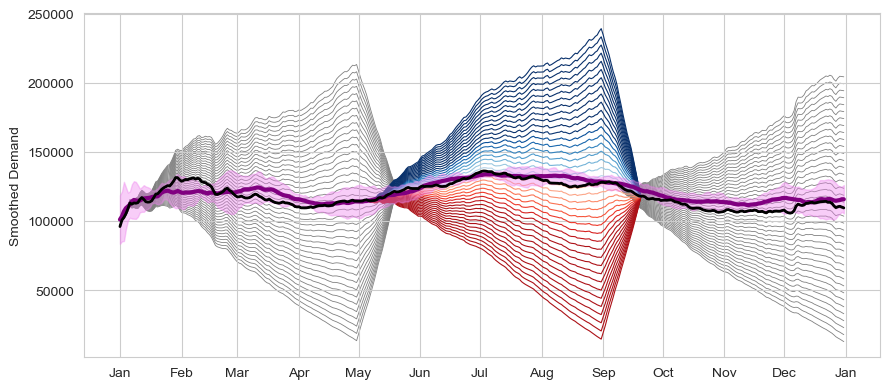

In [23]:
periods = [
    ("2018-01-01", "2018-04-30", "P1"),
    ("2018-05-01", "2018-08-31", "P2"),
    ("2018-09-01", "2018-12-31", "P3"),
]

zxc = plot_variations(periods, rolling_factor = 20)

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

def plot_demand_by_config(
    period_id="P1",
    scale_id="s100",
    num_feats=1,
    data_root="data_leaks/benchmark/energy",
    smooth=False,
    window=30,
    figsize=(14, 6)
):
    """
    Plot demand for each client for a specific (period, scale, num_feats) config.

    Parameters
    ----------
    period_id : {"P1","P2","P3"}
        Drifted period identifier.
    scale_id  : str
        Scaling level identifier (e.g., "s+10", "s100", "s-10").
    num_feats : int
        Number of uninformative features (1–5).
    data_root : str
        Root directory where all client subfolders are saved.
    smooth    : bool
        Whether to apply centered rolling average to demand.
    window    : int
        Window size for smoothing.
    figsize   : tuple
        Size of the plot.

    Returns
    -------
    None
    """

    # ------------------------------------------------------------------
    # 1. Locate the target folder
    # ------------------------------------------------------------------
    subdir = f"{period_id}_{scale_id}_{num_feats}feats"
    target_dir = os.path.join(data_root, subdir)

    if not os.path.isdir(target_dir):
        print(f"Directory '{target_dir}' not found.")
        return

    # ------------------------------------------------------------------
    # 2. Collect all client CSVs in that folder
    # ------------------------------------------------------------------
    pattern = re.compile(r"Client([A-Z])\.csv$", re.I)
    files = [
        f for f in os.listdir(target_dir)
        if pattern.match(f)
    ]
    if not files:
        print(f"No client files found in '{target_dir}'.")
        return

    # ------------------------------------------------------------------
    # 3. Read each client file and convert timestamp to datetime
    # ------------------------------------------------------------------
    client_data = []
    for fname in sorted(files):
        fpath = os.path.join(target_dir, fname)
        df_cli = pd.read_csv(fpath)

        # Convert timestamp (seconds) to datetime assuming base date Jan 1, 2018
        df_cli['date'] = pd.to_datetime('2018-01-01') + pd.to_timedelta(df_cli['timestamp'], unit='s')
        df_cli['client'] = pattern.match(fname).group(1)

        if smooth:
            df_cli['demand_plot'] = (
                df_cli['demand']
                .rolling(window=window, center=True, min_periods=1)
                .mean()
            )
        else:
            df_cli['demand_plot'] = df_cli['demand']

        client_data.append(df_cli[['date', 'demand_plot', 'client']])

    plot_df = pd.concat(client_data, ignore_index=True)

    # ------------------------------------------------------------------
    # 4. Plot
    # ------------------------------------------------------------------
    sns.set_style("whitegrid")
    plt.figure(figsize=figsize)

    sns.lineplot(
        data=plot_df,
        x="date",
        y="demand_plot",
        hue="client",
        palette="tab10"
    )

    # Set monthly locator and formatter for x-axis
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))

    title = (
        f"Demand – {period_id}, scale {scale_id}, {num_feats} uninformative feature"
        + ("s" if num_feats > 1 else "")
        + (" (smoothed)" if smooth else " (raw)")
    )
    plt.title(title)
    plt.xlabel("Month")
    plt.ylabel("Demand")
    plt.tight_layout()
    plt.show()


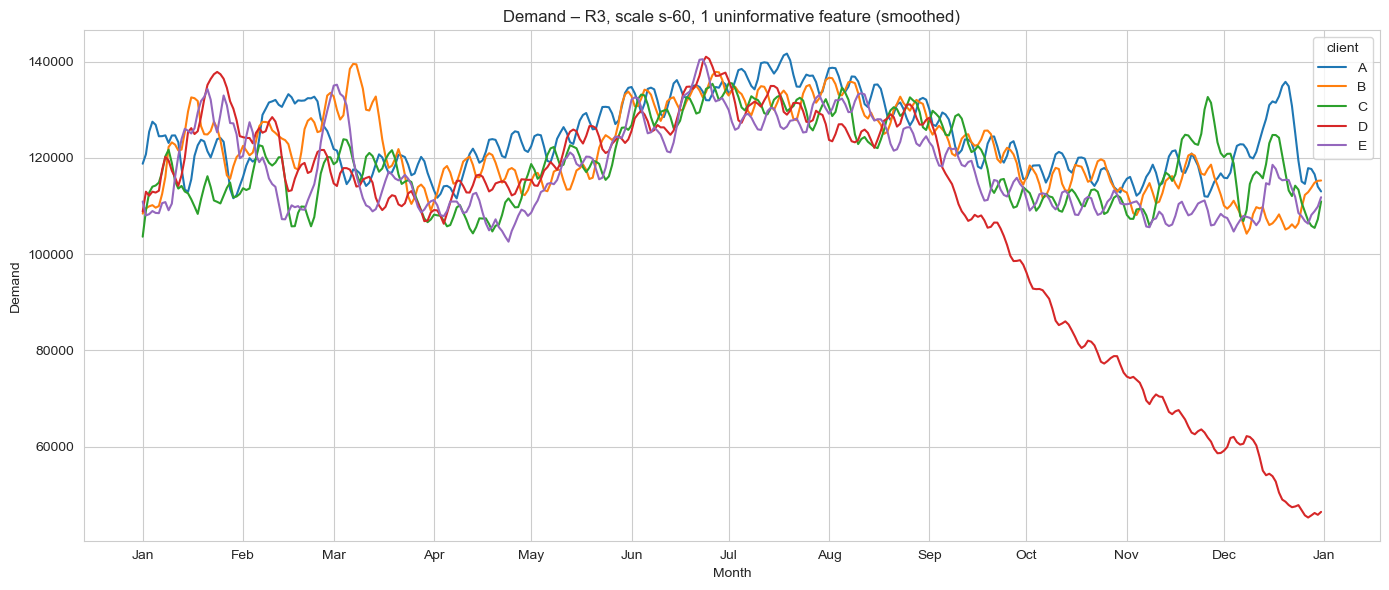

In [9]:
plot_demand_by_config(period_id="R3", scale_id="s-60", num_feats=1, smooth=True, window=10)

In [10]:
import pandas as pd
import os
import glob
from collections import defaultdict

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle

from sklearn.metrics.pairwise import cosine_distances


def combined_value_counts(df, normalize=False, sort_index=True):
    """
    Compute value counts (and optionally normalized percentages) of combinations
    of multiple columns in a DataFrame.

    Parameters:
    - df: DataFrame with the columns to group by.
    - normalize: If True, return relative frequencies.
    - sort_index: If True, sort the result by index.

    Returns:
    - A DataFrame with a MultiIndex (column combinations) and columns ['count', 'percent'].
    """
    # Raw counts
    counts = df.value_counts(normalize=False)
    percents = df.value_counts(normalize=True)

    # Combine into one DataFrame
    result = pd.DataFrame({
        'count': counts,
        'percent': percents
    })

    if normalize:
        result.drop(columns='count', inplace=True)

    if sort_index:
        result = result.sort_index()

    return result


def client_self_cosine_drift(data_latent):
    features = [col for col in data_latent.columns if col.startswith('x_')]
    results = []

    for client_id, group in data_latent.groupby('client_id'):
        group_sorted = group.sort_values('label')  # Ensure chronological order
        vectors = group_sorted[features].values
        labels = group_sorted['label'].values

        if len(vectors) < 2:
            continue  # Skip clients with only one label

        # First and last vectors
        first_vector = vectors[0].reshape(1, -1)


        # 2. Distance of first label to all later labels
        for i in range(1, len(vectors)):
            res = {
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[0],
                'drift_type': 'first_vs_later',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), first_vector)[0][0],
            }
            results.append(res)

        # 3. Rolling (Consecutive)
        for i in range(len(vectors) - 1):
            results.append({
                'client_id': client_id,
                'label': labels[i],
                'compared_to': labels[i + 1],
                'drift_type': 'rolling',
                'cosine_distance': cosine_distances(vectors[i].reshape(1, -1), vectors[i + 1].reshape(1, -1))[0][0],
            })

    return pd.DataFrame(results)


def rank_clients_by_drift(df, periods):
    # 1. Filter out unwanted labels
    # df = df[~df['label'].isin([11, 12])].copy()

    # 3. Store results in a dictionary
    ranked_results = {}

    for period_name, valid_labels in periods.items():
        df_period = df[df['label'].isin(valid_labels)].copy()

        # === a) Per-label RANKING ===
        df_period['rank'] = df_period.groupby(['drift_type', 'label'])['cosine_distance']\
                                     .rank(method='dense', ascending=False)

        # === b) Summary STATS (mean and sum per client) ===
        agg_stats = df_period.groupby(['drift_type', 'client_id'])['cosine_distance']\
                             .agg(['mean', 'sum'])\
                             .rename(columns={'mean': 'mean_distance', 'sum': 'sum_distance'})\
                             .reset_index()

        # === c) Rank clients by mean and sum ===
        agg_stats['rank_by_mean'] = agg_stats.groupby('drift_type')['mean_distance']\
                                             .rank(method='dense', ascending=False)

        agg_stats['rank_by_sum'] = agg_stats.groupby('drift_type')['sum_distance']\
                                            .rank(method='dense', ascending=False)

        # Store both the detailed and summary DataFrames
        ranked_results[period_name] = {
            'detailed': df_period,
            'summary': agg_stats
        }

    return ranked_results


def analyze_experiments_by_epoch(data, periods = None, epochs = None, top_n=1):
    if periods is None:
        periods = {
            'all_periods': list(range(0, 12))
        }

    results = {}

    for experiment in data:
        results[experiment] = {}

        data_path = os.path.join(experiment, 'Baseline_latent_space.parquet')
        new_latent = pd.read_parquet(data_path)

        experiment_summary_rows = []

        epochs_loop = epochs if epochs is not None else new_latent['epoch'].sort_values().unique()
        for epoch in epochs_loop:
            results[experiment][epoch] = {}

            data_epoch = new_latent[
                (new_latent['epoch'].astype(str) == str(epoch)) &
                (new_latent['client_id'].str.contains('_proto'))
            ]

            if data_epoch.empty:
                print(f'    ⚠ No data for epoch {epoch}, skipping...')
                continue

            df_drift = client_self_cosine_drift(data_epoch)
            ranked = rank_clients_by_drift(df_drift, periods)

            compiled_summaries = {}

            for period_name, result in ranked.items():
                summary = result['summary'].copy()

                summary['experiment'] = experiment
                summary['epoch'] = epoch
                summary['period'] = period_name

                # Rank delta
                summary['rank_diff'] = (summary['rank_by_mean'] - summary['rank_by_sum']).abs()

                # Collect for experiment-level summary
                experiment_summary_rows.append(summary)

                # Top-N for both rank types
                top_by_mean = summary.sort_values(['drift_type', 'rank_by_mean']).groupby('drift_type').head(top_n)
                top_by_mean['rank_type'] = 'mean'

                top_by_sum = summary.sort_values(['drift_type', 'rank_by_sum']).groupby('drift_type').head(top_n)
                top_by_sum['rank_type'] = 'sum'

                compiled = pd.concat([top_by_mean, top_by_sum], ignore_index=True)
                compiled.sort_values(by=['drift_type', 'rank_type'], inplace=True)

                compiled_summaries[period_name] = compiled

            results[experiment][epoch]['ranked'] = ranked
            results[experiment][epoch]['compiled_summary'] = compiled_summaries


        # 🔄 Per-Experiment Global Analysis
        if experiment_summary_rows:
            exp_df = pd.concat(experiment_summary_rows, ignore_index=True)

            # === 1. Average Ranks + Rank Delta ===
            avg_ranks = exp_df.groupby(['client_id', 'drift_type'])[
                ['rank_by_mean', 'rank_by_sum', 'rank_diff']
            ].mean().reset_index()
            avg_ranks.rename(columns={
                'rank_by_mean': 'avg_rank_by_mean',
                'rank_by_sum': 'avg_rank_by_sum',
                'rank_diff': 'avg_rank_delta'
            }, inplace=True)

            # === 2. Stability Index (Top-N appearances) ===
            stability_counts = defaultdict(lambda: {'mean': 0, 'sum': 0})
            for _, row in exp_df.iterrows():
                if row['rank_by_mean'] <= top_n:
                    stability_counts[(row['client_id'], row['drift_type'])]['mean'] += 1
                if row['rank_by_sum'] <= top_n:
                    stability_counts[(row['client_id'], row['drift_type'])]['sum'] += 1

            stability_df = pd.DataFrame([
                {
                    'client_id': cid,
                    'drift_type': drift_type,
                    'stability_topN_mean': counts['mean'],
                    'stability_topN_sum': counts['sum']
                }
                for (cid, drift_type), counts in stability_counts.items()
            ])

            # === 3. Combine metrics
            experiment_metrics = avg_ranks.merge(stability_df, on=['client_id', 'drift_type'], how='outer')
            results[experiment]['summary_metrics'] = experiment_metrics
            results[experiment]['all_summary_df'] = exp_df

        else:
            results[experiment]['summary_metrics'] = pd.DataFrame()
            results[experiment]['all_summary_df'] = pd.DataFrame()

    return results

import pandas as pd

def extract_best_clients_by_summary_metrics(results_dict, periods_list):
    """
    Extract the top client (lowest avg_rank_by_mean) per drift_type for each experiment,
    based on the summary_metrics table.

    Parameters:
        results_dict (dict): Structure like:
            results[experiment]['summary_metrics']

    Returns:
        pd.DataFrame: DataFrame with top clients per drift_type per experiment,
                      plus drift detection diagnostics.
    """
    top_clients_all_experiments = []

    for experiment_name, experiment_data in results_dict.items():
        summary_metrics = experiment_data.get('summary_metrics')

        if summary_metrics is None or summary_metrics.empty:
            continue

        # For each drift_type, get the client with the lowest avg_rank_by_mean
        top_clients_df = (
            summary_metrics
            .sort_values(['drift_type', 'avg_rank_by_mean'])
            .groupby('drift_type')
            .head(1)
            .copy()
        )

        top_clients_df['experiment'] = experiment_name
        top_clients_df['period'] = 'all_year'

        # Retain only necessary columns
        top_clients_all_experiments.append(top_clients_df[['client_id', 'drift_type', 'experiment', 'period']])

    # Combine all experiments into one DataFrame
    summary_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add derived/diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] =  'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df


def extract_best_clients_by_ranked_summary_initial(results_dict, periods_list, rank_func = 'mean'):
    """
    For each experiment, extract clients that most frequently rank highest (rank_by_mean == 1)
    across epochs, per drift_type.

    Parameters:
        results_dict (dict): Nested structure:
            results[experiment][epoch]['ranked']['first_4_months']['summary']

    Returns:
        pd.DataFrame: DataFrame with top clients per drift_type per experiment, plus diagnostics.
    """
    top_clients_all_experiments = []

    for period in periods_list: #['first_4_months','middle_year', 'final_year']:
        for experiment_name, experiment_data in results_dict.items():
            top_rows_per_epoch = []

            for epoch in list(experiment_data.keys())[:-2]:
                epoch_key = str(epoch)
                if epoch_key not in experiment_data:
                    continue

                summary_df = experiment_data[epoch_key]['ranked'][period]['summary']
                if summary_df.empty:
                    continue

                top_rank_df = summary_df[summary_df[f'rank_by_{rank_func}'] == 1].copy()
                top_rank_df['epoch'] = epoch
                top_rows_per_epoch.append(top_rank_df)

            # Skip experiment if no qualifying rows
            if not top_rows_per_epoch:
                continue

            # Combine across epochs
            combined_epoch_df = pd.concat(top_rows_per_epoch, ignore_index=True)

            # Count appearances of each client at rank 1 per drift_type
            client_rank_counts = (
                combined_epoch_df.groupby(['drift_type', 'client_id'])
                .size()
                .reset_index(name='count')
            )

            # Select clients with the highest count per drift_type
            max_counts_per_drift = client_rank_counts.groupby('drift_type')['count'].transform('max')
            top_clients_df = client_rank_counts[client_rank_counts['count'] == max_counts_per_drift].copy()
            top_clients_df['experiment'] = experiment_name
            top_clients_df['period'] = period

            top_clients_all_experiments.append(top_clients_df[['client_id', 'drift_type', 'experiment', 'period']])

    # Combine results from all experiments
    summary_df = pd.concat(top_clients_all_experiments, ignore_index=True)

    # Add diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] =  'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df



def extract_best_clients_by_max_cosine_distance(results_dict, periods_list):
    """
    For each experiment and epoch, identify clients with the maximum cosine_distance
    per drift_type, and count which clients appear most often across epochs.

    Parameters:
        results_dict (dict): Nested results dictionary with structure:
            results[experiment][epoch]['ranked']['first_4_months']['detailed']

    Returns:
        pd.DataFrame: Summary DataFrame with top clients per drift_type per experiment,
                      and additional columns for analysis.
    """
    best_clients_all_experiments = []

    for period in periods_list: #['first_4_months','middle_year', 'final_year']:

        for experiment_name, experiment_data in results_dict.items():
            max_cosine_rows_per_epoch = []

            for epoch in list(experiment_data.keys())[:-2]:
                detailed_df = experiment_data[str(epoch)]['ranked'][period]['detailed']

                # Keep only rank 1 entries
                rank_1_df = detailed_df[detailed_df['rank'] == 1]

                # For each drift_type, select the row with max cosine_distance
                max_cosine_df = rank_1_df.loc[
                    rank_1_df.groupby('drift_type')['cosine_distance'].idxmax()
                ].copy()

                max_cosine_df['epoch'] = epoch
                max_cosine_rows_per_epoch.append(max_cosine_df)

            # Combine epochs for this experiment
            combined_epochs_df = pd.concat(max_cosine_rows_per_epoch)

            # Count how many times each client appears as top cosine_distance per drift_type
            client_counts = (
                combined_epochs_df.groupby(['drift_type', 'client_id'])
                .size()
                .reset_index(name='count')
            )

            # Keep only clients with the highest count per drift_type
            max_count_per_drift = client_counts.groupby('drift_type')['count'].transform('max')
            top_clients = client_counts[client_counts['count'] == max_count_per_drift].copy()
            top_clients['experiment'] = experiment_name
            top_clients['period'] = period

            best_clients_all_experiments.append(top_clients[['client_id', 'drift_type', 'experiment', 'period']])


    # Combine across all experiments
    summary_df = pd.concat(best_clients_all_experiments, ignore_index=True)

    # Add derived/diagnostic columns
    summary_df['client_drift'] = summary_df['client_id'].str.split('_').str[1]
    summary_df['ground_truth'] = 'D' #summary_df['experiment'].str.replace('results\\', '', regex=False).str[0]
    summary_df['check'] = summary_df['client_drift'] == summary_df['ground_truth']

    return summary_df

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_extraction_methods(setup_dict, results, extractors, periods_list):
    """
    Evaluate multiple extraction methods on different experiment setups,
    return a DataFrame with normalized accuracy results, and plot them.

    Parameters:
        setup_dict (dict): Mapping from setup name to list of experiment names.
        results (dict): Main results dictionary.
        extractors (list of tuples): List of (label, extraction_function).

    Returns:
        pd.DataFrame: Combined summary of correct/wrong % per drift_type, setup, and method.
    """
    all_ct_results = []
    summary_list = []
    for setup_name, experiment_list in setup_dict.items():
        experiment_subset = {exp: results[exp] for exp in experiment_list}

        for label, extract_func in extractors:
            print(f'{setup_name} - {label.upper()}')
            if 'rank' in label:
                rank_func = label.split('_')[-1]
                summary_df = extract_func(experiment_subset, periods_list, rank_func)
            else:
                summary_df = extract_func(experiment_subset, periods_list)
            summary_df['exp_id'] = summary_df['experiment'].str[15:24]

            summary_list.append(summary_df)
            # Crosstab: % correct and wrong per drift_type
            crosstab = (
                pd.crosstab([summary_df['exp_id'], summary_df['period'], summary_df['drift_type']], summary_df['check'], normalize='index') * 100
            ).round(2)

            crosstab.rename(columns={True: 'correct_%', False: 'wrong_%'}, inplace=True)
            # crosstab['drift_type'] = crosstab.index
            crosstab['setup'] = setup_name
            crosstab['method'] = label
            all_ct_results.append(crosstab.reset_index())

    # Combine into single DataFrame
    ct_summary_df = pd.concat(all_ct_results, ignore_index=True)

    return ct_summary_df, summary_list

In [11]:
exp_id = 'BENCHMARK_ENERGY_FINAL_AGORAVAI'

folders_experiment = [f for f in glob.glob(os.path.join('results/energy', '*BENCHMARK_ENERGY_FINAL_BOREXPS_2018*')) if os.path.isdir(f)]

# folders_experiment = [f for f in folders_experiment if '_10_' in f]

# 2. Define the periods
periods = {
    'first_4_months': list(range(0, 4)),
    'middle_year': list(range(4, 8)),
    'final_year': list(range(7, 12)),
    'all_periods': list(range(0, 12)),
}

# periods = {
#     'first_4_months': list(range(0, 5)),
#     'middle_year': list(range(3, 9)),
#     'final_year': list(range(6, 12)),
#     'all_periods': list(range(0, 12)),
# }

results = analyze_experiments_by_epoch(data = folders_experiment, epochs = ['0','1','2'], periods = periods)

possible_exps = set([exp.split('__')[-2] for exp in list(results.keys())])

setup_dict = {}
for setup in possible_exps:
    exps_setup = [exp for exp in list(results.keys()) if setup in exp]
    setup_dict[setup] = exps_setup

extraction_methods = [
    ("max cosine", extract_best_clients_by_max_cosine_distance),
    ("rank cosine_mean", extract_best_clients_by_ranked_summary_initial),
    ("rank cosine_sum", extract_best_clients_by_ranked_summary_initial),
    ("summary", extract_best_clients_by_summary_metrics),
]

results_evaluation, summary_df = evaluate_extraction_methods(setup_dict, results, extraction_methods, list(periods.keys()))

# Create a combined category for drift_type and setup
results_evaluation['setup'] = results_evaluation['setup'].apply(
    lambda s: '_'.join(s.split('_')[:-1] + [str(int(int(s.split('_')[-1]) / 3600))])
)

_12_5_86400 - MAX COSINE
_12_5_86400 - RANK COSINE_MEAN
_12_5_86400 - RANK COSINE_SUM
_12_5_86400 - SUMMARY
_5_10_86400 - MAX COSINE
_5_10_86400 - RANK COSINE_MEAN
_5_10_86400 - RANK COSINE_SUM
_5_10_86400 - SUMMARY
_5_20_86400 - MAX COSINE
_5_20_86400 - RANK COSINE_MEAN
_5_20_86400 - RANK COSINE_SUM
_5_20_86400 - SUMMARY
_12_10_86400 - MAX COSINE
_12_10_86400 - RANK COSINE_MEAN
_12_10_86400 - RANK COSINE_SUM
_12_10_86400 - SUMMARY
_15_5_86400 - MAX COSINE
_15_5_86400 - RANK COSINE_MEAN
_15_5_86400 - RANK COSINE_SUM
_15_5_86400 - SUMMARY
_5_5_86400 - MAX COSINE
_5_5_86400 - RANK COSINE_MEAN
_5_5_86400 - RANK COSINE_SUM
_5_5_86400 - SUMMARY
_12_20_86400 - MAX COSINE
_12_20_86400 - RANK COSINE_MEAN
_12_20_86400 - RANK COSINE_SUM
_12_20_86400 - SUMMARY


In [34]:
import pickle

save_results = {
    'data_analysis' : results,
    'evaluation' : results_evaluation,
    'data_evaluation' : summary_df
}

with open(f'results/energy/traceback/experiment__{exp_id.lower()}.pkl', 'wb') as f:
    pickle.dump(save_results, f)

In [163]:
# import pickle
# with open('results/imgs/experiment_benchmark_energy_BOM.pkl', 'wb') as f:
#     pickle.dump(results, f)

In [12]:
# import pickle
# with open('results/imgs/experiment_benchmark_energy_analysis_final.pkl', 'rb') as f:
#     plot_data = pickle.load(f)

In [47]:
qwe = data_exp[data_exp['correct_%'] == 100]
qwe = qwe[qwe['setup'] == '_12_10_24']
qwe = qwe[qwe['period'] == 'first_4_months']
qwe = qwe[qwe['method'] == 'rank cosine_mean']
qwe = qwe[qwe['drift_interval'] == 'P1']
qwe = qwe[qwe['drift_positive']]

qwe

check,exp_id,period,drift_type,wrong_%,correct_%,setup,method,drift_interval,drift_power,feats,drift_positive
1389,R1_s+75_1,first_4_months,rolling,0.0,100.0,_12_10_24,rank cosine_mean,P1,s+75,1,True
1397,R1_s+80_1,first_4_months,rolling,0.0,100.0,_12_10_24,rank cosine_mean,P1,s+80,1,True
1405,R1_s+85_1,first_4_months,rolling,0.0,100.0,_12_10_24,rank cosine_mean,P1,s+85,1,True
1413,R1_s+90_1,first_4_months,rolling,0.0,100.0,_12_10_24,rank cosine_mean,P1,s+90,1,True
1421,R1_s+95_1,first_4_months,rolling,0.0,100.0,_12_10_24,rank cosine_mean,P1,s+95,1,True


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Classify detection per (exp_id, period)
def classify_drift_detection(group):
    types_detected = set(group.loc[group['detected'], 'drift_type'])
    if types_detected == {'first_vs_later'}:
        return 'first_only'
    elif types_detected == {'rolling'}:
        return 'rolling_only'
    elif types_detected == {'first_vs_later', 'rolling'}:
        return 'both'
    else:
        return 'none'

def classify_drift_detection_wrapper(group):
    # drop grouping columns manually
    group_data = group.drop(columns=['exp_id', 'period', 'setup'], errors='ignore')

    label = classify_drift_detection(group_data)

    return pd.Series({'detection_label': label})


def label_based_color(row):
    label = row['detection_label']
    drift_power = row['drift_power']

    if pd.isnull(label):
        return 'black'
    if label == 'both':
        return 'gray'
    if '+' in drift_power:
        sign = '+'
    elif '-' in drift_power:
        sign = '-'
    else:
        return 'black'

    if 'rolling' in label:
        return 'blue' if sign == '+' else 'red'
    if 'first' in label:
        return 'green' if sign == '+' else 'purple'
    return 'black'

def parse_drift_power(val):
    try:
        return int(val.replace('s', '').replace('+', ''))
    except Exception:
        return None


def process_results(data_evaluation, method = 'summary'):
    # --- 1. Preprocessing ---
    data_exp = data_evaluation.copy()

    # Extract metadata from exp_id
    data_exp[['drift_interval', 'drift_power', 'feats']] = (
        data_exp['exp_id'].str.replace('R', 'P').str.split('_', expand=True)
    )
    data_exp['drift_positive'] = data_exp['drift_power'].str.contains(r'\+')
    data_exp['feats'] = data_exp['feats'].str.replace('f', '')
    data_exp = data_exp[data_exp['feats'] == '1']

    # Filter for method
    data_exp = data_exp[data_exp['method'] == method].copy()

    # Flag detection
    data_exp['detected'] = data_exp['correct_%'] != 0


    # Group the data
    grouped = data_exp.groupby(['setup', 'exp_id', 'period'], group_keys=False)

    # Apply function and avoid deprecated behavior manually
    drift_labels = grouped.apply(classify_drift_detection_wrapper, include_groups=False).reset_index()
    drift_labels.columns = ['setup', 'exp_id', 'period', 'detection_label']

    # Merge results back
    data_exp = data_exp.merge(drift_labels, on=['setup', 'exp_id', 'period'], how='left')

    # Composite identifier for y-axis
    data_exp['drift_exp'] = data_exp['drift_type'] + " | " + data_exp['feats']

    # --- 2. Define color mapping ---

    # Assign color
    data_exp['color'] = data_exp.apply(label_based_color, axis=1)


    data_exp['period'] = data_exp['period'].str.replace('all_periods', 'Ano completo')
    data_exp['period'] = data_exp['period'].str.replace('first_4_months', '1_trimestre')
    data_exp['period'] = data_exp['period'].str.replace('middle_year', '2_trimestre')
    data_exp['period'] = data_exp['period'].str.replace('final_year', '3_trimestre')
    data_exp['period'] = data_exp['period'].str.replace('all_year', 'Ano sumarizado')


    data_exp['drift_power_num'] = data_exp['drift_power'].apply(parse_drift_power)
    # --- 3. Plot per (period, drift_interval) ---
    periods = sorted(data_exp['period'].unique())
    intervals = sorted(data_exp['drift_interval'].unique())

    data_exp['period_interval'] = data_exp['period'] + "__" + data_exp['drift_interval']
    return data_exp

In [30]:
data_exp_rank = process_results(data_evaluation = results_evaluation, method = 'rank cosine_mean')
data_exp_summary = process_results(data_evaluation = results_evaluation, method = 'summary')

data_exp = pd.concat([data_exp_rank, data_exp_summary])
data_exp.head()

,exp_id,period,drift_type,wrong_%,correct_%,setup,method,drift_interval,drift_power,feats,drift_positive,detected,detection_label,drift_exp,color,drift_power_num,period_interval
0,P1_s+05_1,Ano completo,first_vs_later,100.0,0.0,_12_5_24,rank cosine_mean,P1,s+05,1,True,False,none,first_vs_later | 1,black,5,Ano completo__P1
1,P1_s+05_1,Ano completo,rolling,100.0,0.0,_12_5_24,rank cosine_mean,P1,s+05,1,True,False,none,rolling | 1,black,5,Ano completo__P1
2,P1_s+05_1,3_trimestre,first_vs_later,100.0,0.0,_12_5_24,rank cosine_mean,P1,s+05,1,True,False,none,first_vs_later | 1,black,5,3_trimestre__P1
3,P1_s+05_1,3_trimestre,rolling,100.0,0.0,_12_5_24,rank cosine_mean,P1,s+05,1,True,False,none,rolling | 1,black,5,3_trimestre__P1
4,P1_s+05_1,1_trimestre,first_vs_later,100.0,0.0,_12_5_24,rank cosine_mean,P1,s+05,1,True,False,none,first_vs_later | 1,black,5,1_trimestre__P1


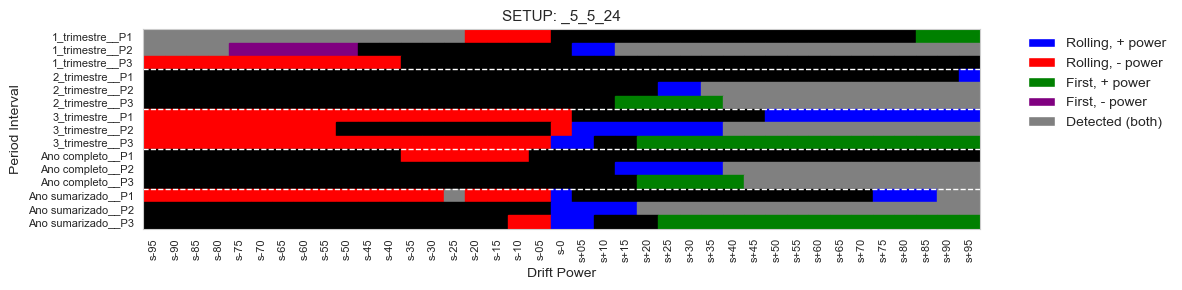

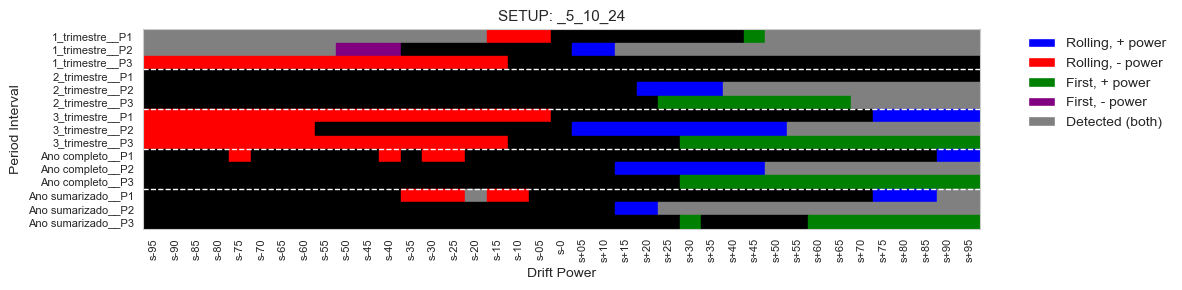

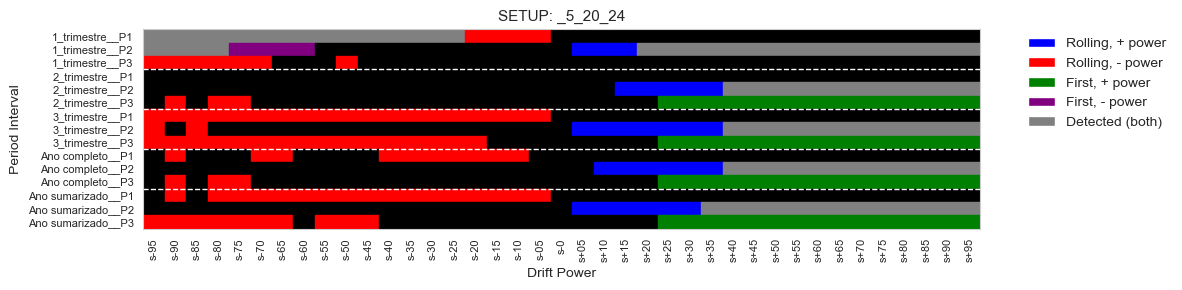

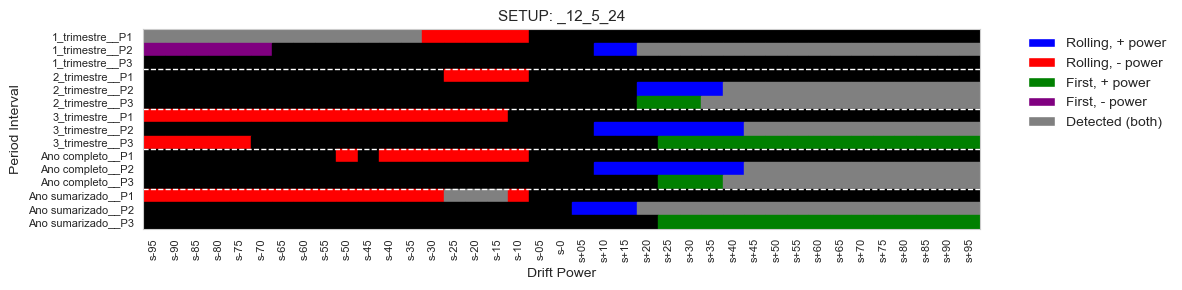

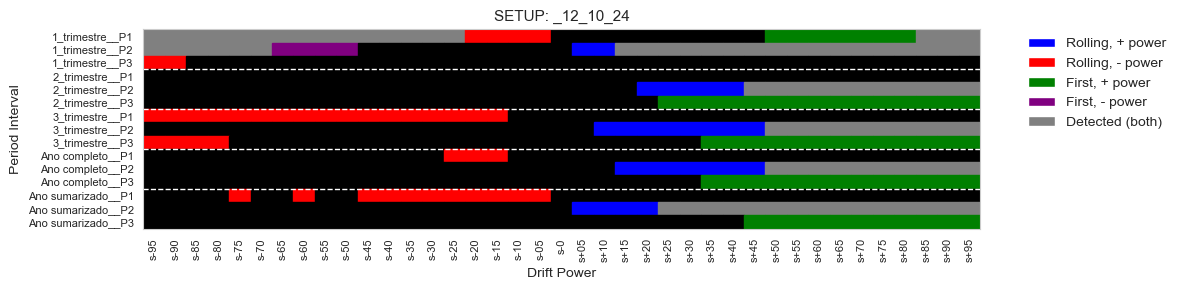

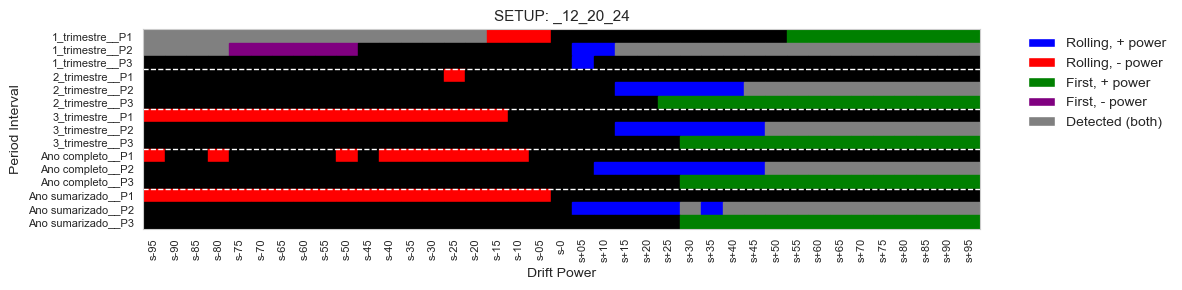

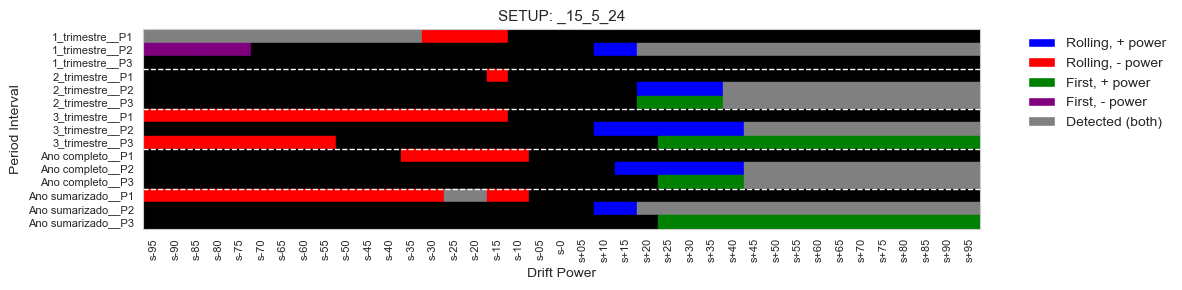

In [31]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Plot with period_interval as y-axis ---
for setup_exp in ['_5_5_24', '_5_10_24', '_5_20_24', '_12_5_24', '_12_10_24', '_12_20_24', '_15_5_24', ]:#data_exp['setup'].unique():
    data_exp_setup = data_exp[data_exp['setup'] == setup_exp]

    fig, ax = plt.subplots(figsize=(10, 3))

    # Filter data
    subset = data_exp_setup[data_exp_setup['drift_power_num'] < 100].copy()
    if subset.empty:
        ax.axis('off')
        continue

    # Sort and pivot
    subset = subset.sort_values('drift_power_num')
    pivot_color = subset.pivot_table(
        index='period_interval',
        columns='drift_power_num',
        values='color',
        aggfunc='first'
    )

    # Get sorted labels
    x_keys = sorted(pivot_color.columns)
    y_labels = list(pivot_color.index)

    # Get drift_power labels (e.g., 's+05') for x-ticks
    drift_power_map = (
        subset[['drift_power_num', 'drift_power']]
        .drop_duplicates()
        .sort_values('drift_power_num')
        .set_index('drift_power_num')['drift_power']
        .to_dict()
    )
    x_labels = [drift_power_map.get(x, str(x)) for x in x_keys]

    # Draw heatmap
    for y_idx, y in enumerate(y_labels):
        for x_idx, x in enumerate(x_keys):
            color = pivot_color.loc[y, x] if x in pivot_color.columns else 'white'
            ax.add_patch(plt.Rectangle((x_idx, y_idx), 1, 1, color=color))

    # Add horizontal separators every 3 rows
    for i in range(3, len(y_labels), 3):
        ax.hlines(i, xmin=0, xmax=len(x_keys), colors='white', linewidth=1, linestyles='dashed')

    # Axes formatting
    ax.set_xticks([k + 0.5 for k in range(len(x_keys))])
    ax.set_xticklabels(x_labels, rotation=90, fontsize=8)
    ax.set_yticks([k + 0.5 for k in range(len(y_labels))])
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_xlim(0, len(x_keys))
    ax.set_ylim(0, len(y_labels))
    ax.invert_yaxis()

    ax.set_title(f"SETUP: {setup_exp}", fontsize=11)
    ax.set_xlabel("Drift Power")
    ax.set_ylabel("Period Interval")

    # Legend
    legend_elements = [
        Patch(facecolor='blue', label='Rolling, + power'),
        Patch(facecolor='red', label='Rolling, - power'),
        Patch(facecolor='green', label='First, + power'),
        Patch(facecolor='purple', label='First, - power'),
        Patch(facecolor='gray', label='Detected (both)'),
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(1.02, 0.9), loc='upper left', frameon=False)

    plt.tight_layout()
    plt.show()

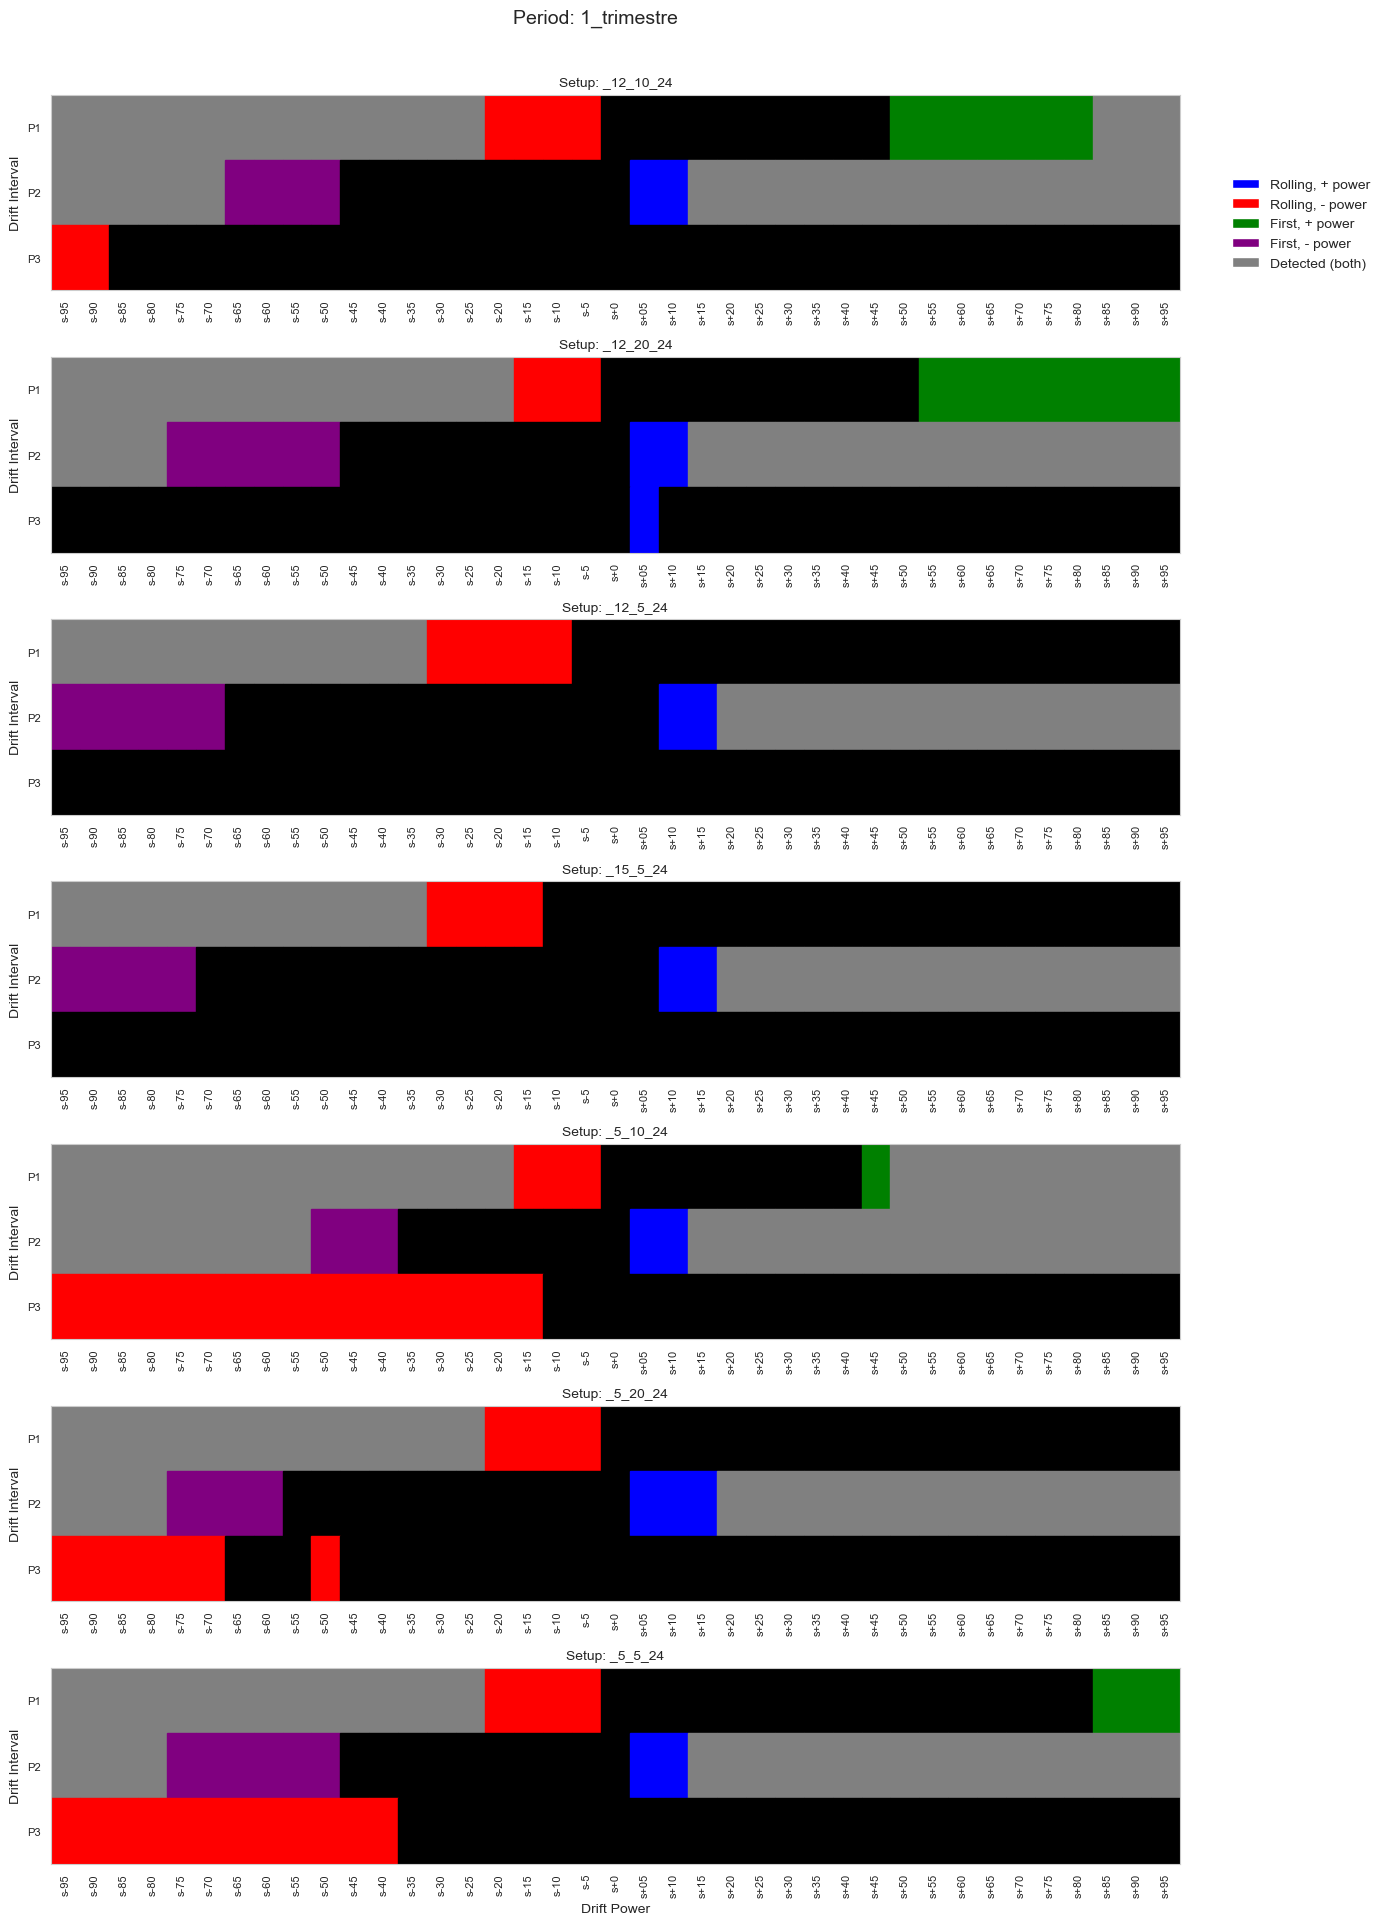

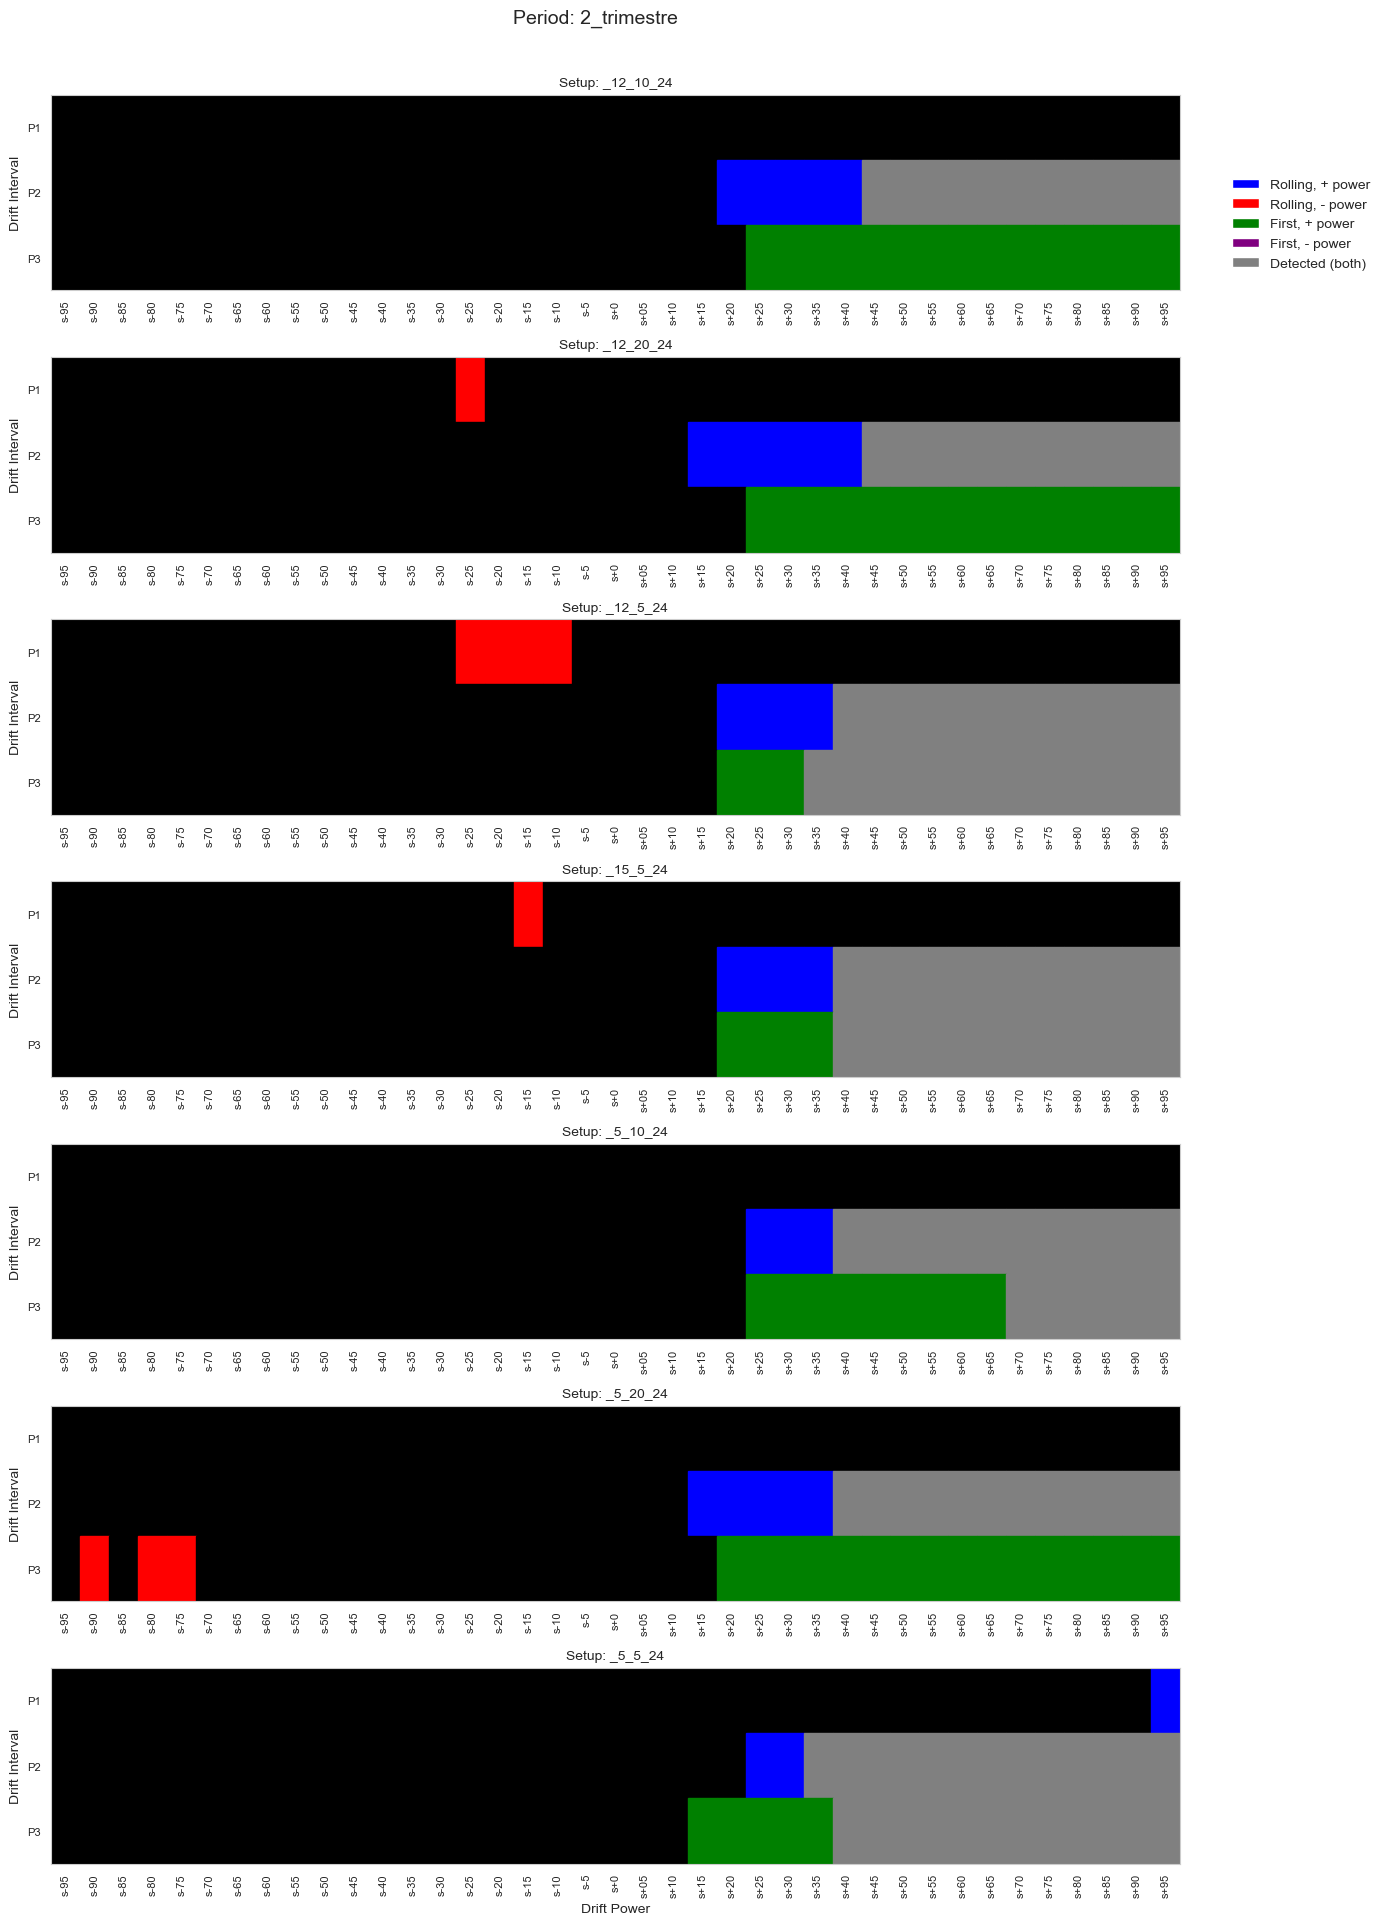

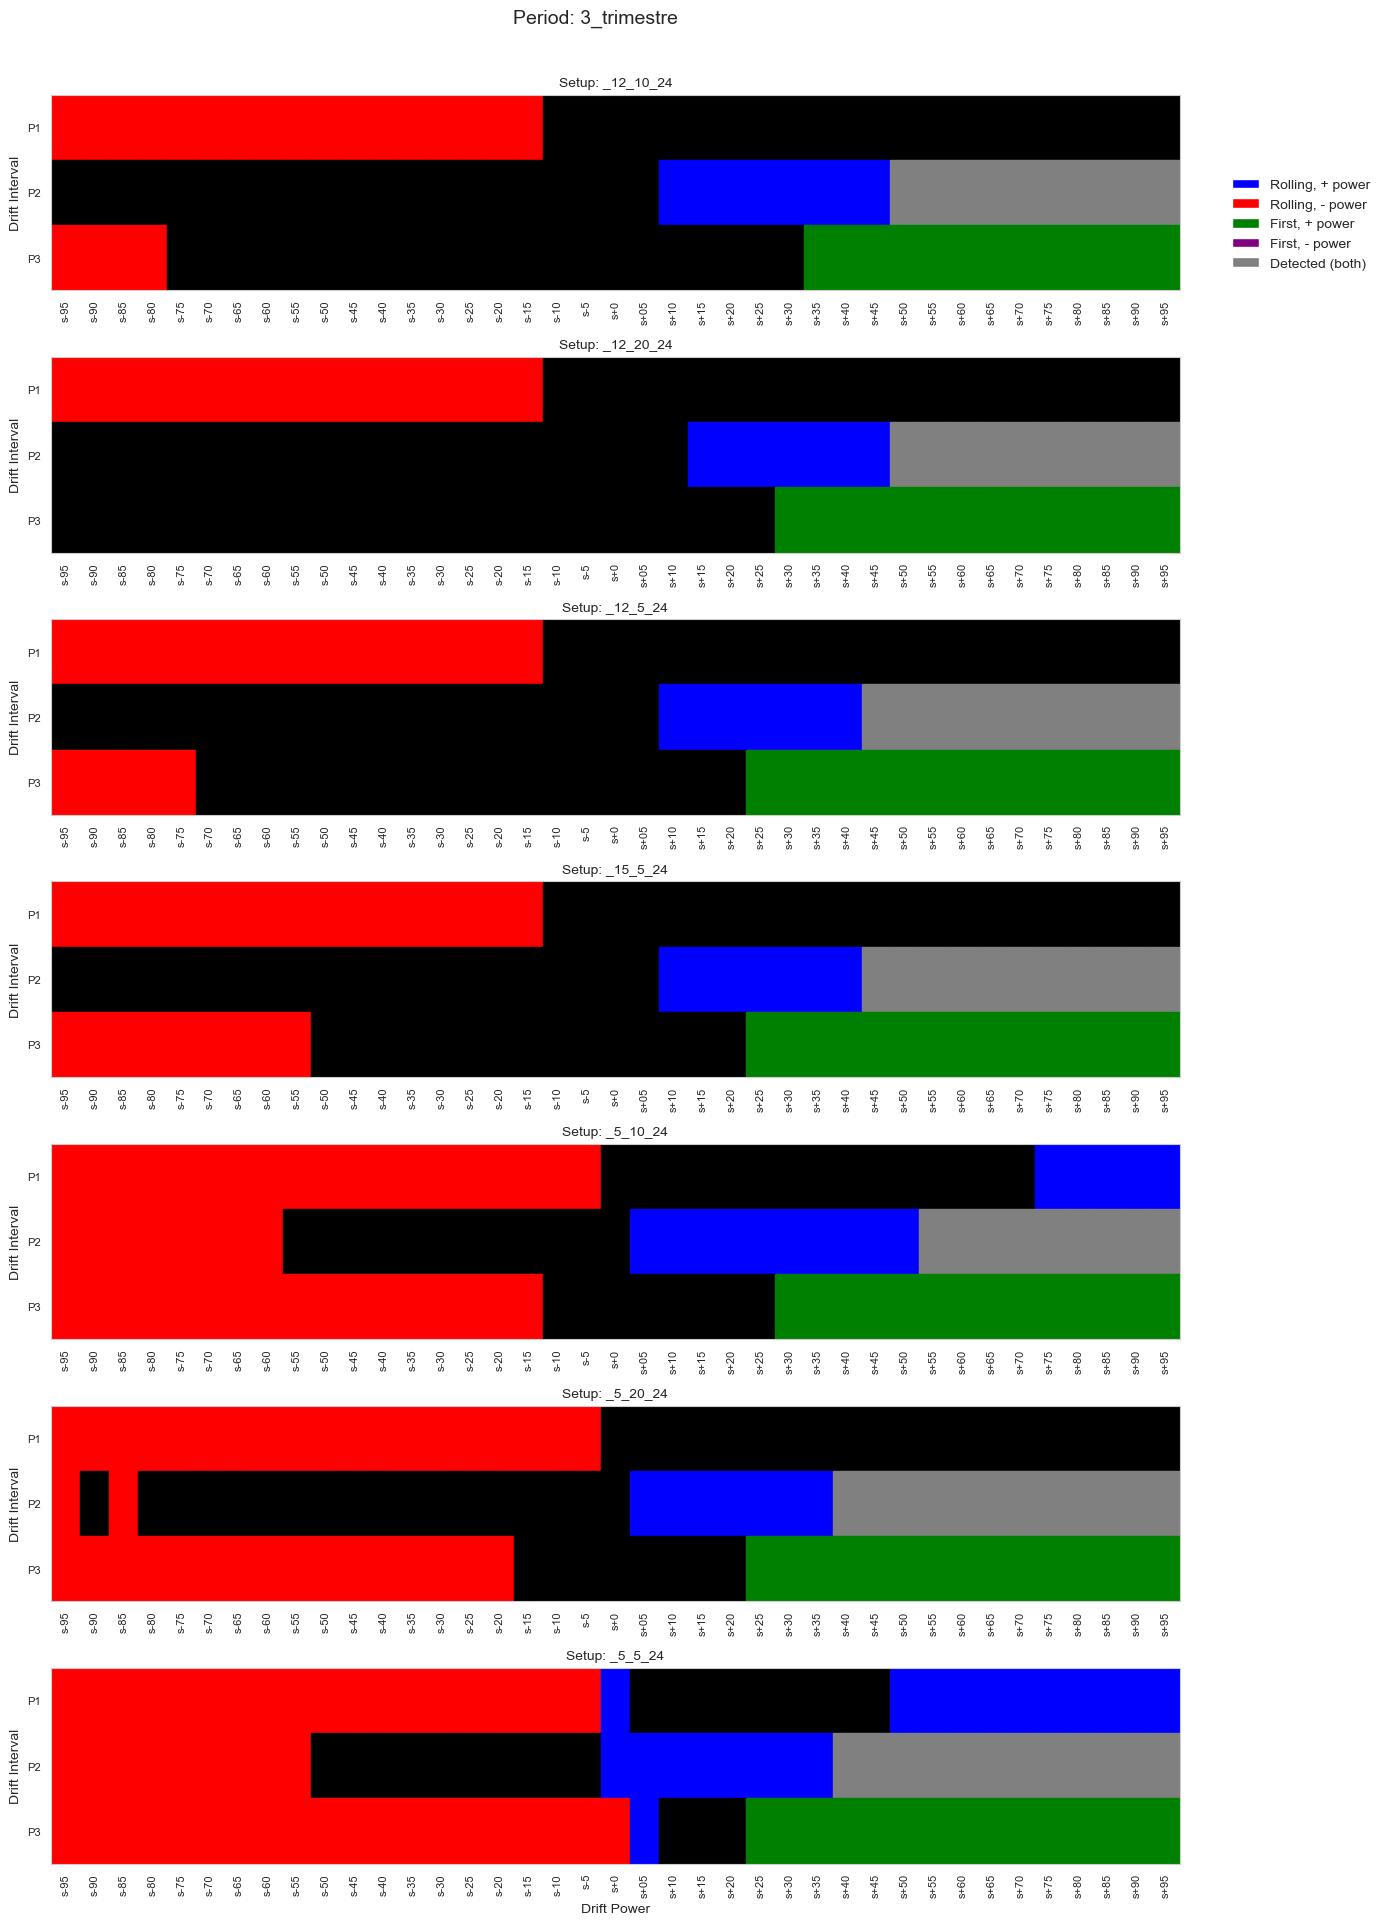

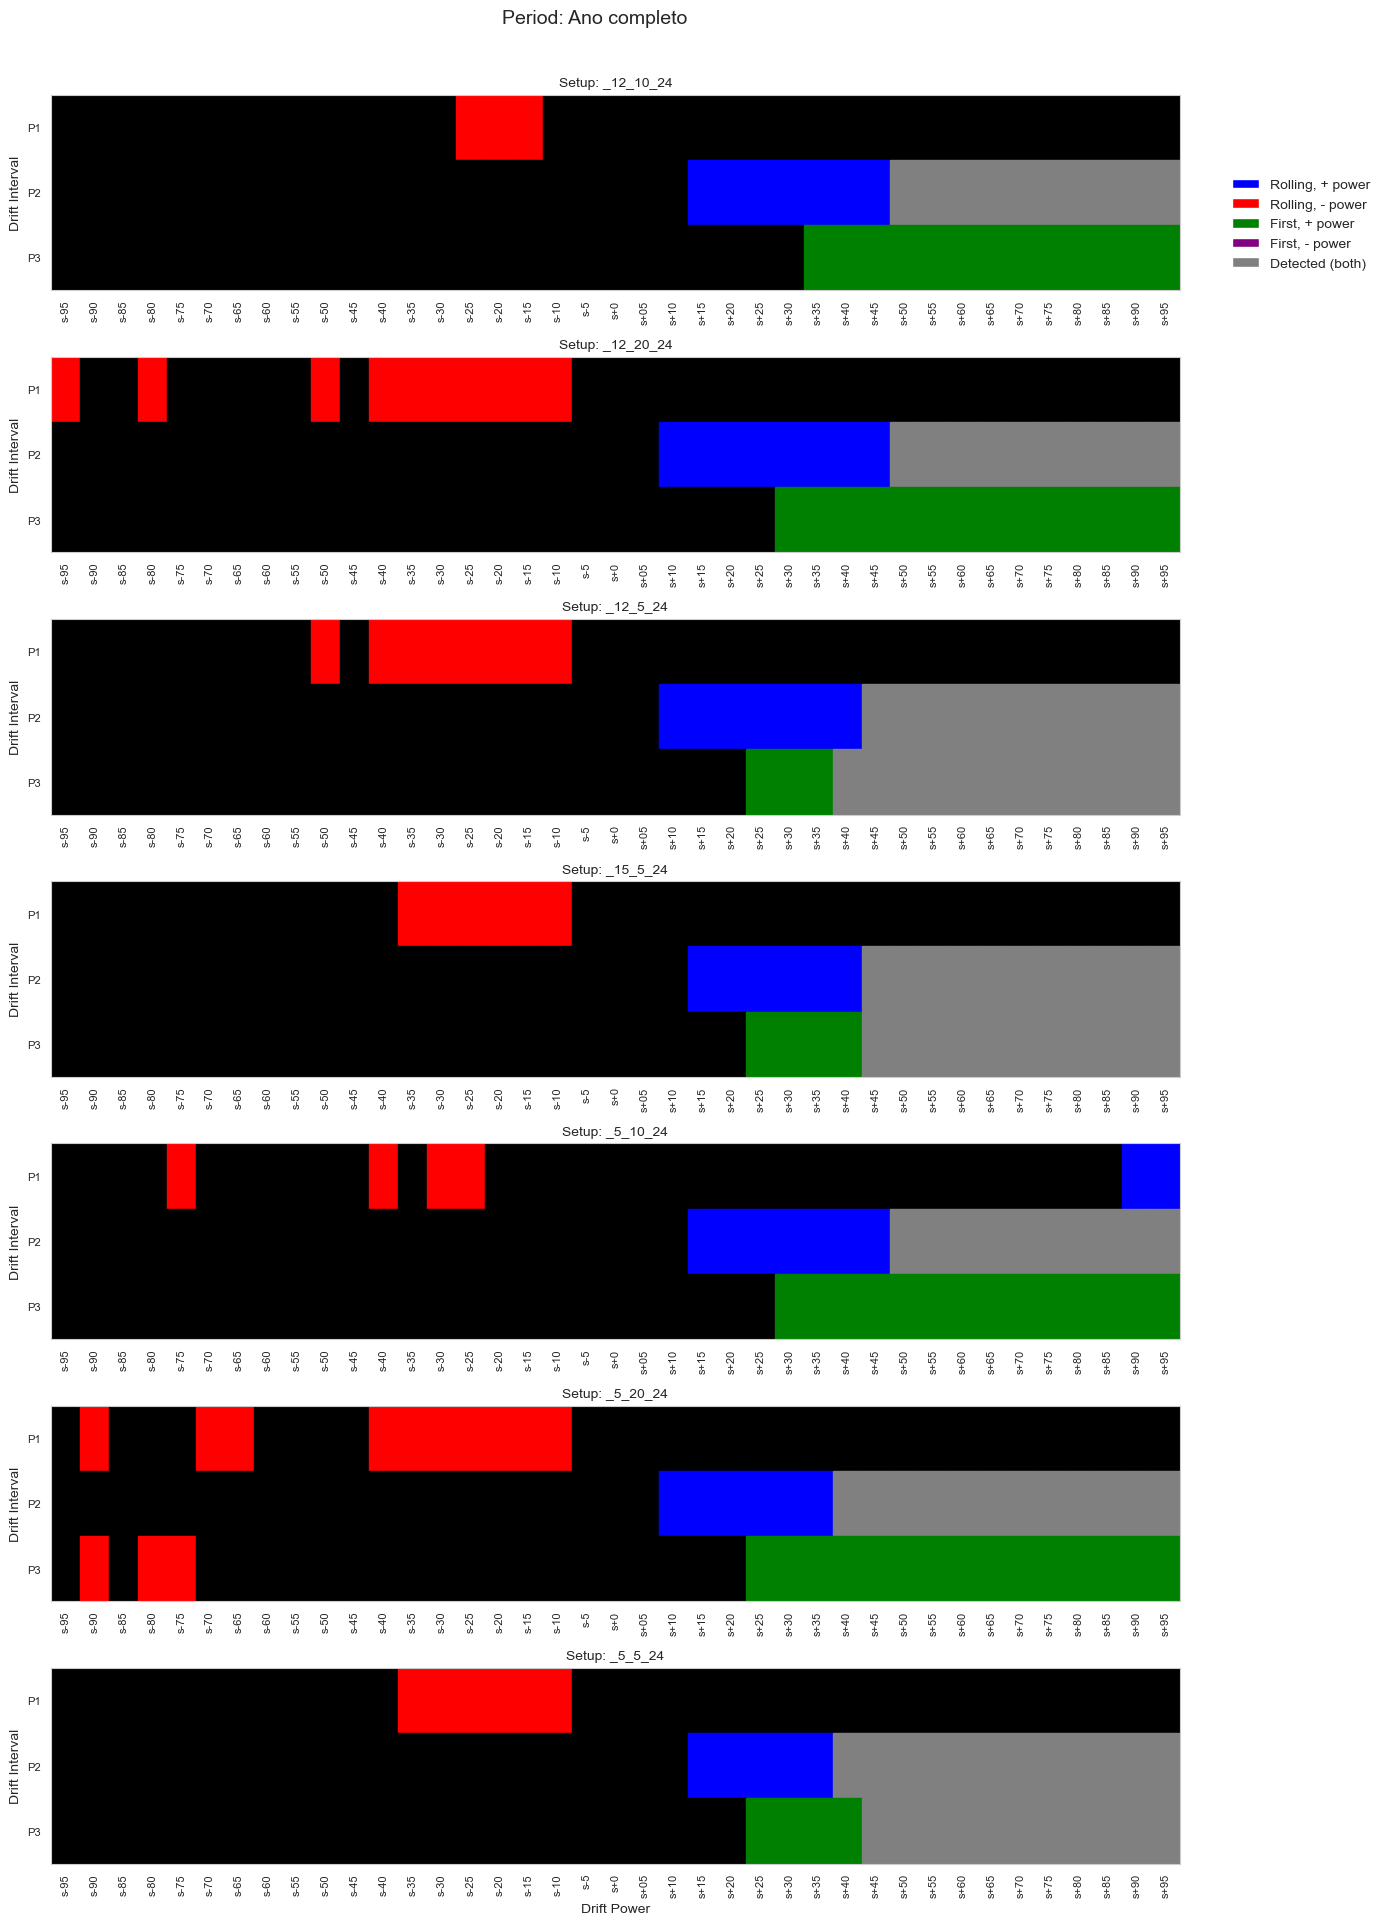

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Ensure drift_power_num exists
def parse_drift_power(val):
    try:
        return int(val.replace('s', '').replace('+', ''))
    except Exception:
        return None

data_exp['drift_power_num'] = data_exp['drift_power'].apply(parse_drift_power)

# --- Extract unique values ---
periods = sorted(data_exp['period'].unique())
setups = sorted(data_exp['setup'].unique())

# --- Plot per period ---
for period in periods:
    fig, axes = plt.subplots(len(setups), 1, figsize=(12, 2.8 * len(setups)), squeeze=False)

    for i, setup_exp in enumerate(setups):
        ax = axes[i][0]

        # Subset for this period and setup
        subset = data_exp[
            (data_exp['period'] == period) &
            (data_exp['setup'] == setup_exp) &
            (data_exp['drift_power_num'] < 100)
        ].copy()

        if subset.empty:
            ax.axis('off')
            continue

        # Pivot table: rows = drift_interval, columns = drift_power_num
        subset = subset.sort_values('drift_power_num')
        pivot_color = subset.pivot_table(
            index='drift_interval',
            columns='drift_power_num',
            values='color',
            aggfunc='first'
        )

        # Prepare labels
        x_keys = sorted(pivot_color.columns)
        y_labels = list(pivot_color.index)

        # Mapping for pretty x-axis labels
        drift_power_map = (
            subset[['drift_power_num', 'drift_power']]
            .drop_duplicates()
            .sort_values('drift_power_num')
            .set_index('drift_power_num')['drift_power']
            .to_dict()
        )
        x_labels = [drift_power_map.get(x, str(x)) for x in x_keys]

        # Draw heatmap cells
        for y_idx, y in enumerate(y_labels):
            for x_idx, x in enumerate(x_keys):
                color = pivot_color.loc[y, x] if x in pivot_color.columns else 'white'
                ax.add_patch(plt.Rectangle((x_idx, y_idx), 1, 1, color=color))

        # Axes formatting
        ax.set_xticks([k + 0.5 for k in range(len(x_keys))])
        ax.set_xticklabels(x_labels, rotation=90, fontsize=8)
        ax.set_yticks([k + 0.5 for k in range(len(y_labels))])
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.set_xlim(0, len(x_keys))
        ax.set_ylim(0, len(y_labels))
        ax.invert_yaxis()

        ax.set_title(f"Setup: {setup_exp}", fontsize=10)
        ax.set_ylabel("Drift Interval")

    # Only add xlabel and legend once (at bottom plot)
    axes[-1][0].set_xlabel("Drift Power")

    legend_elements = [
        Patch(facecolor='blue', label='Rolling, + power'),
        Patch(facecolor='red', label='Rolling, - power'),
        Patch(facecolor='green', label='First, + power'),
        Patch(facecolor='purple', label='First, - power'),
        Patch(facecolor='gray', label='Detected (both)'),
    ]
    fig.suptitle(f"Period: {period}", fontsize=14)
    fig.legend(handles=legend_elements, bbox_to_anchor=(1.02, 0.9), loc='upper left', frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


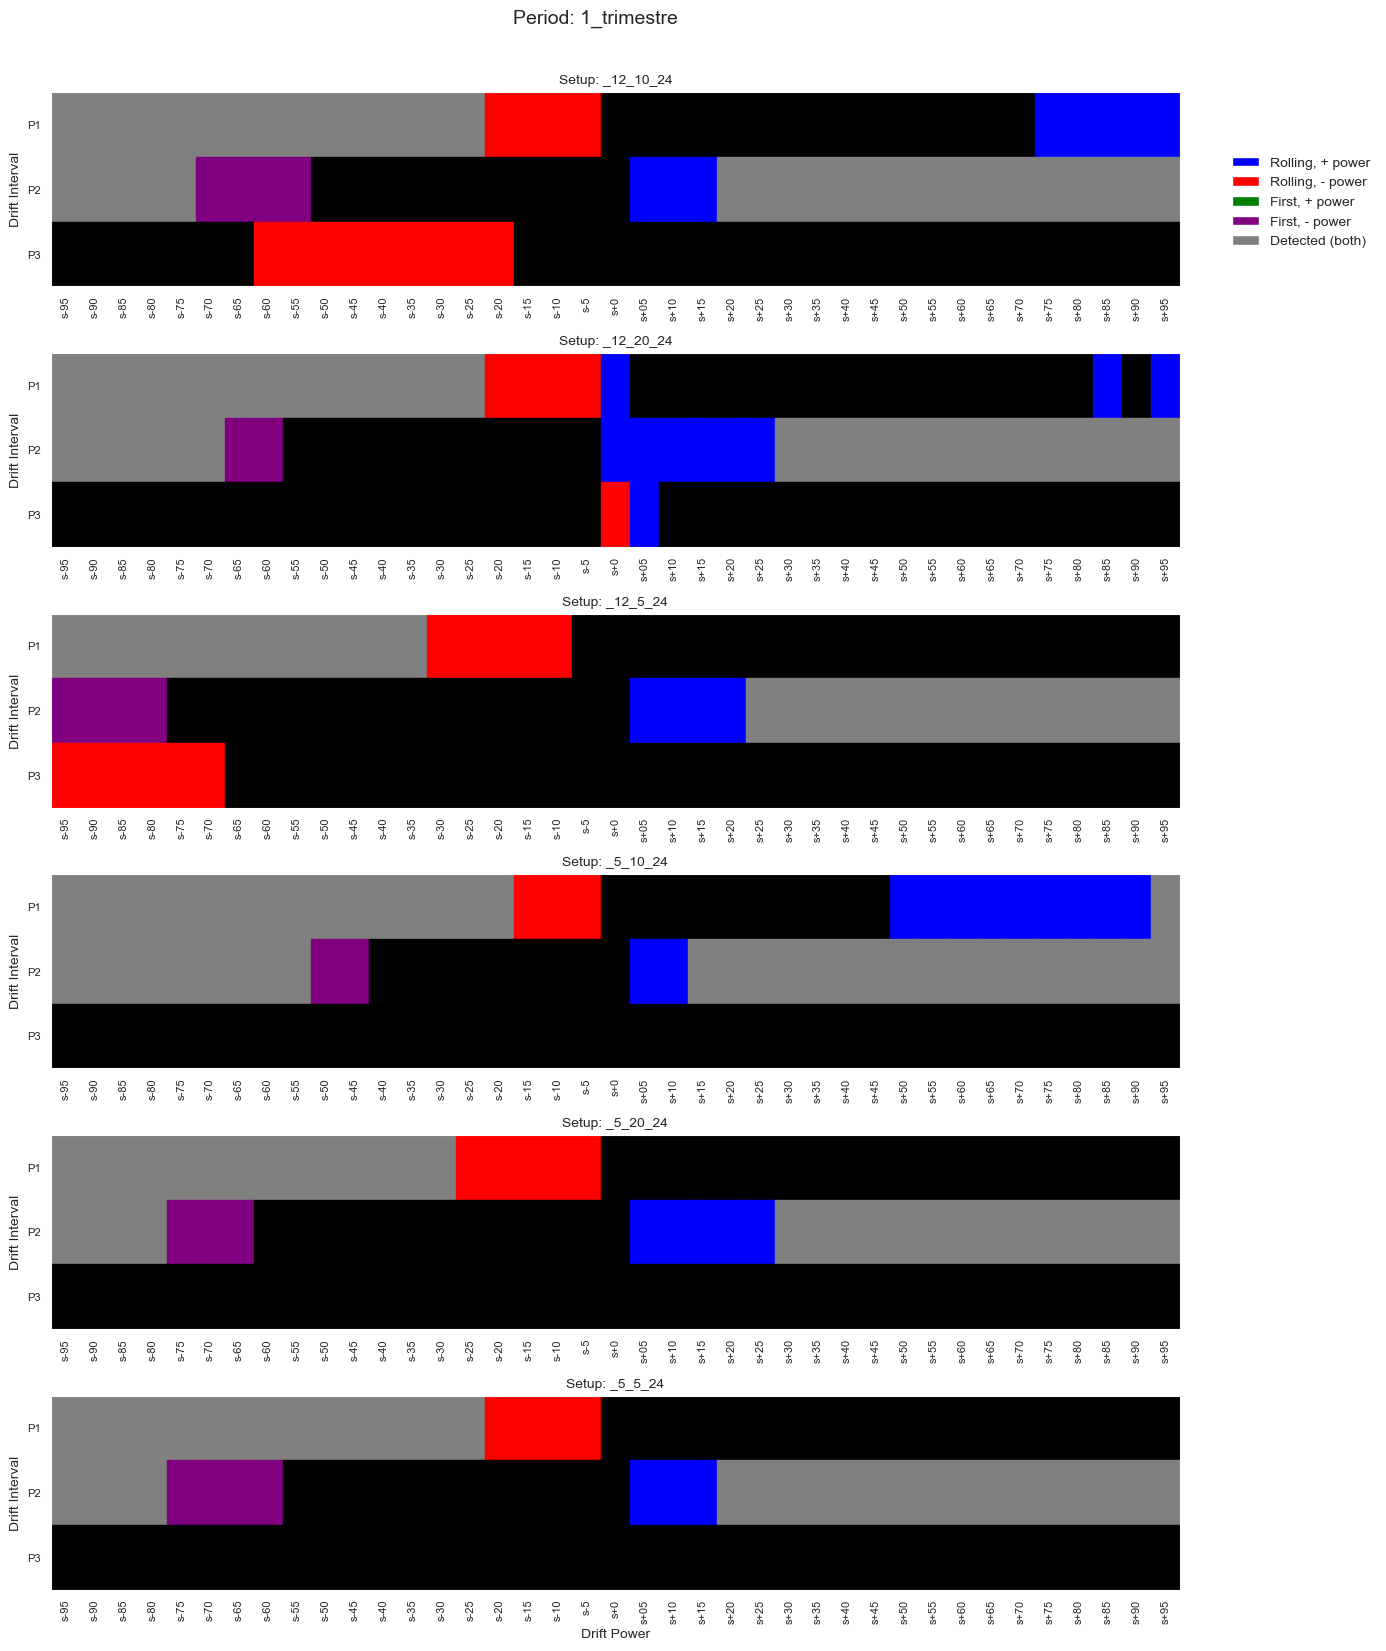

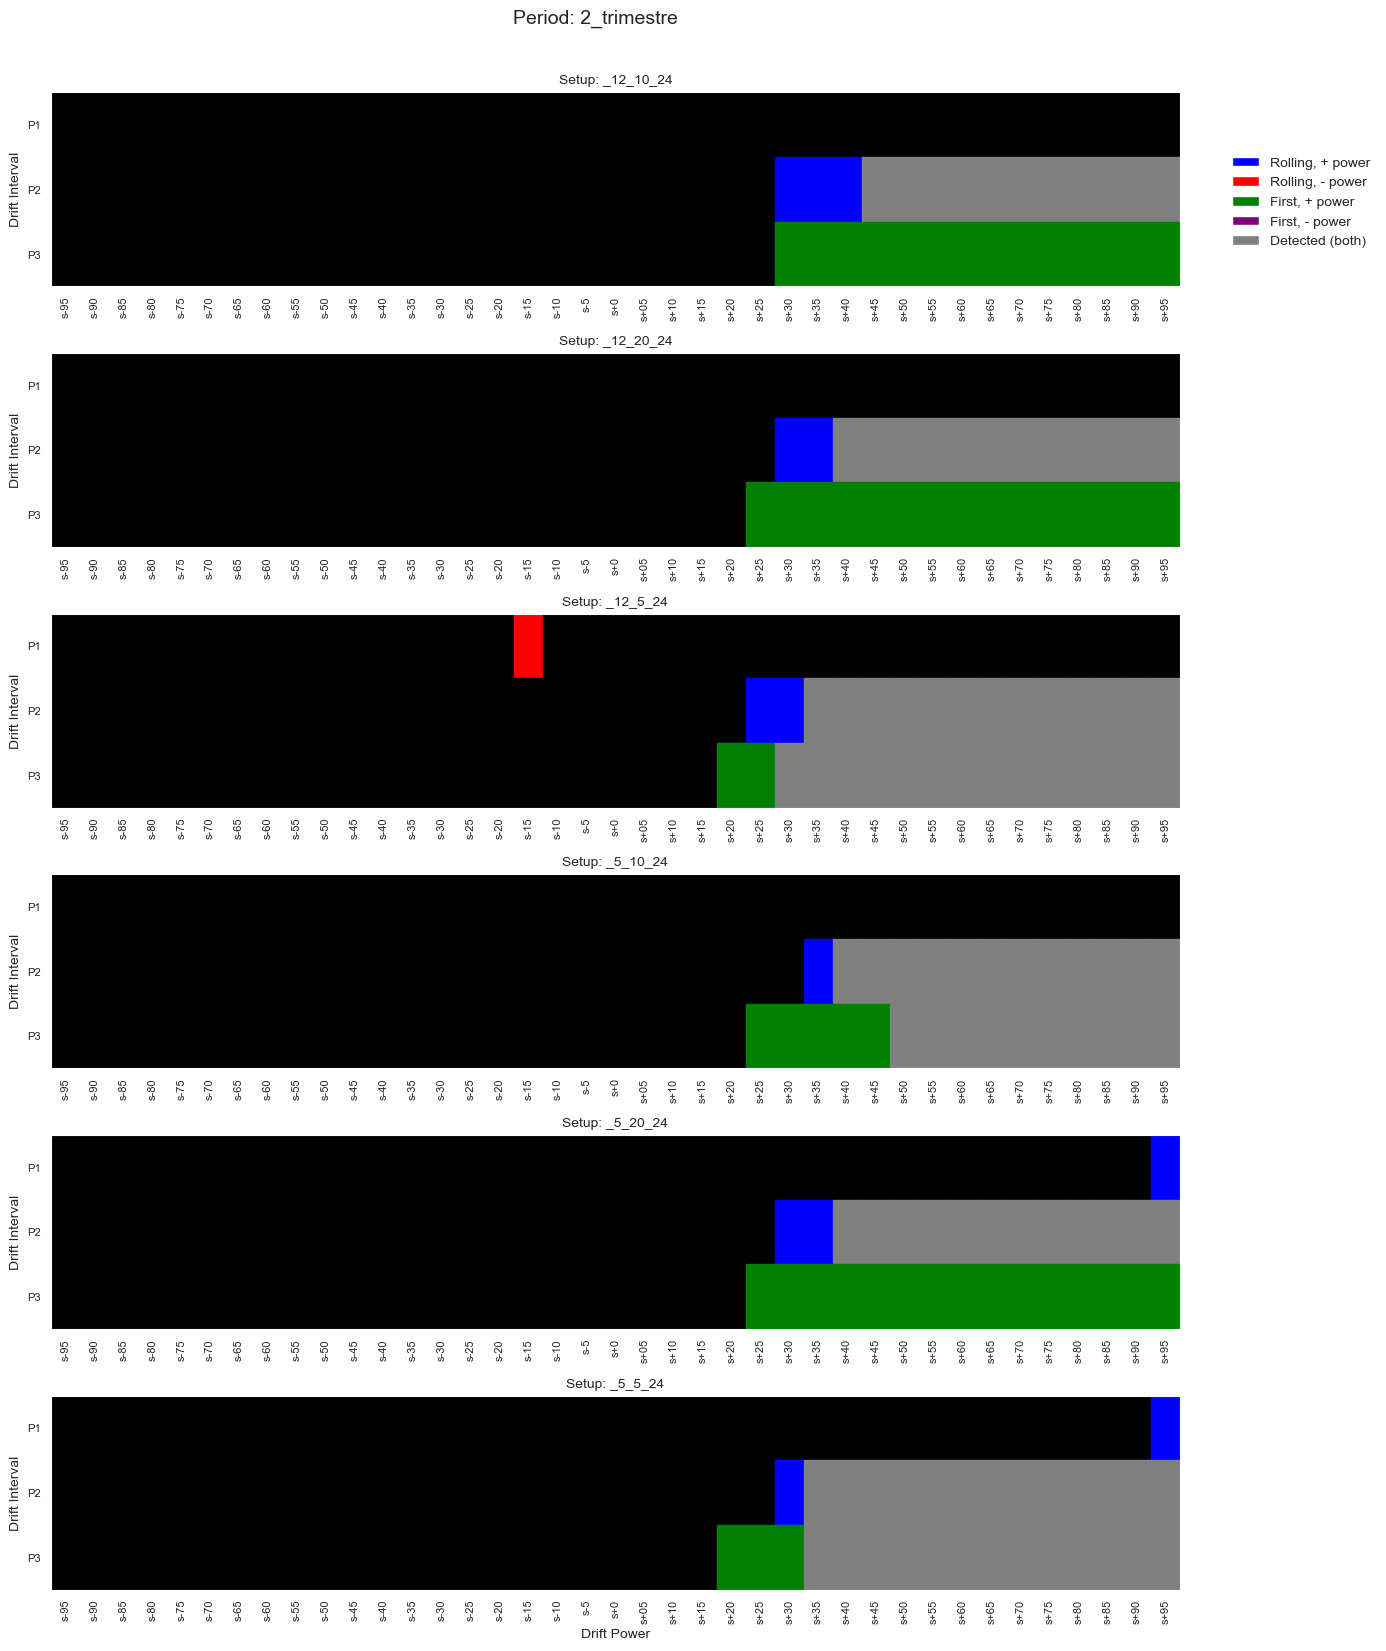

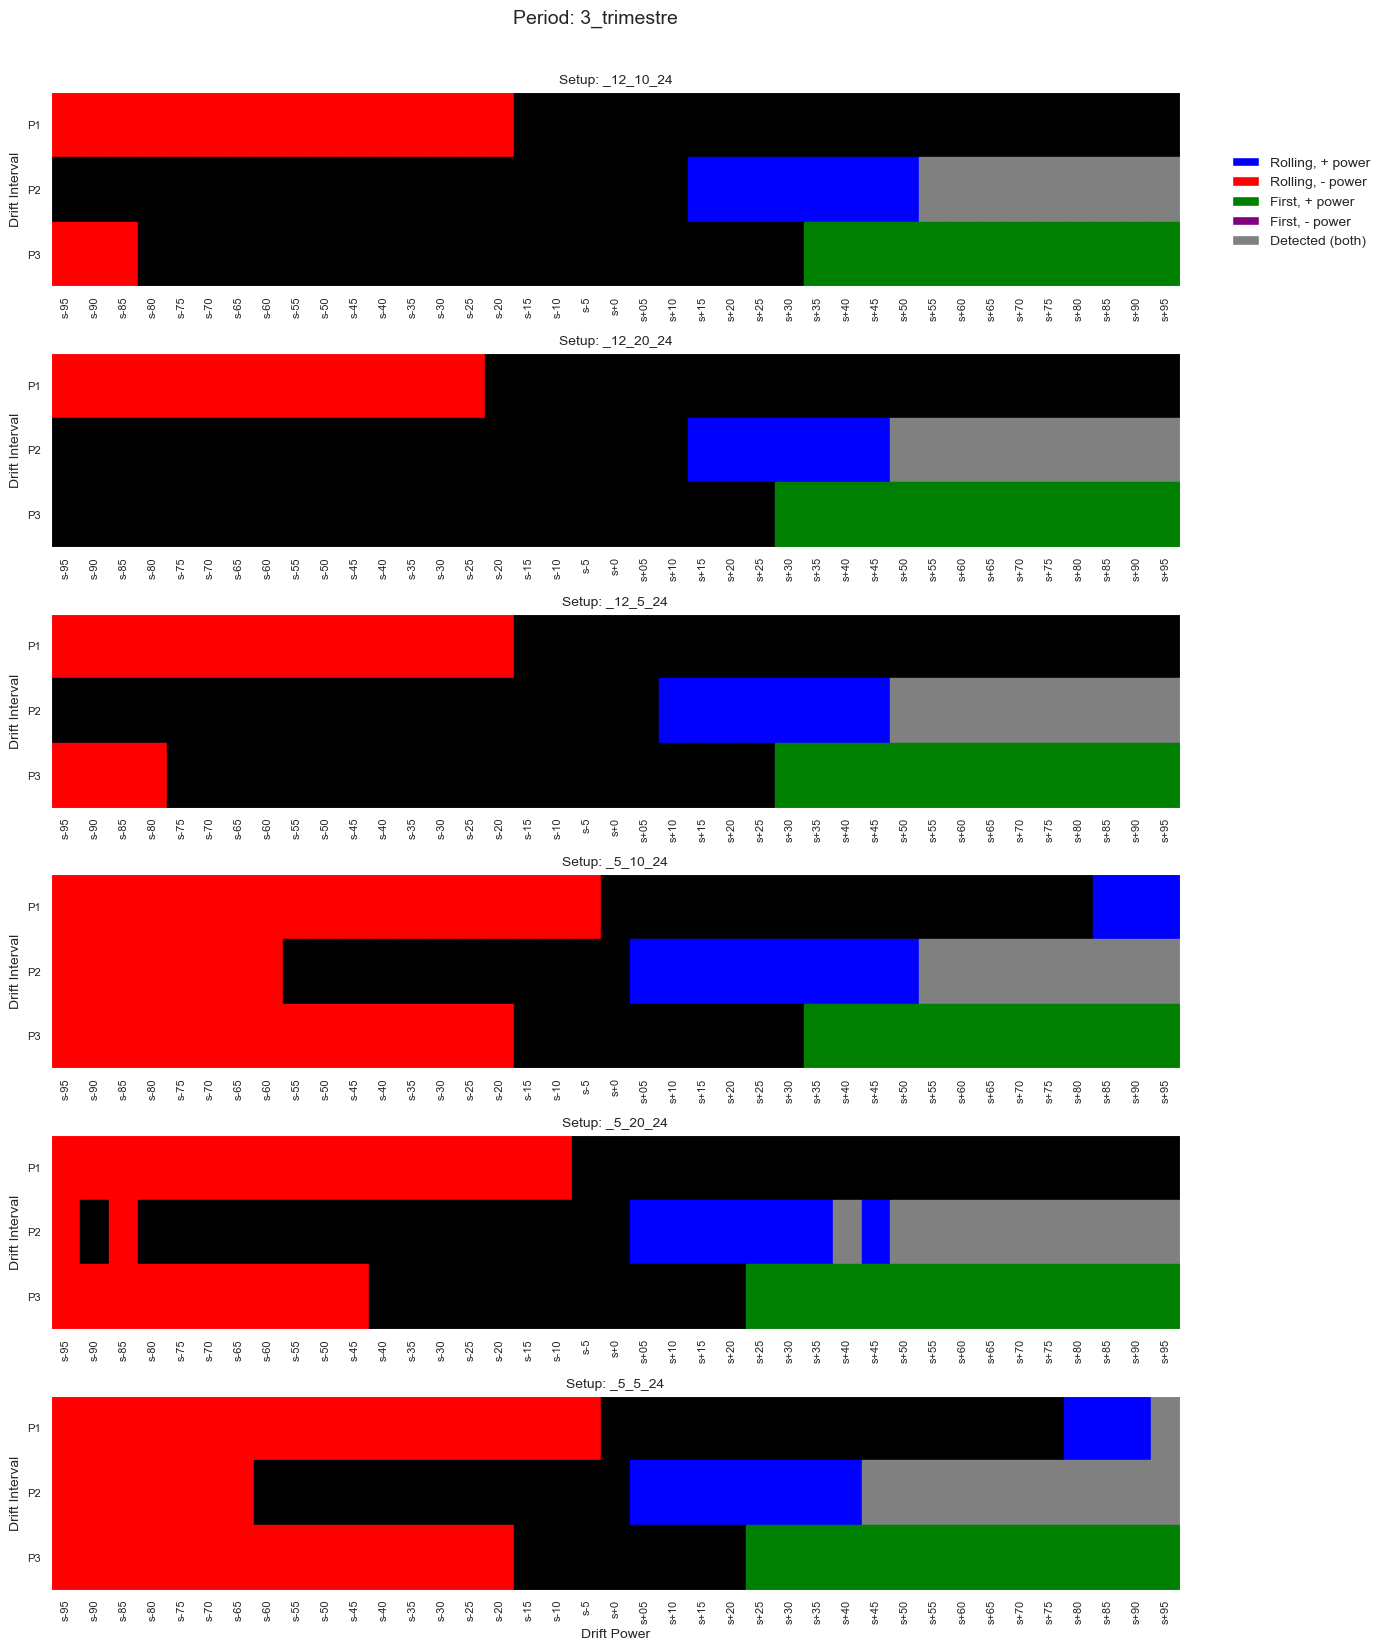

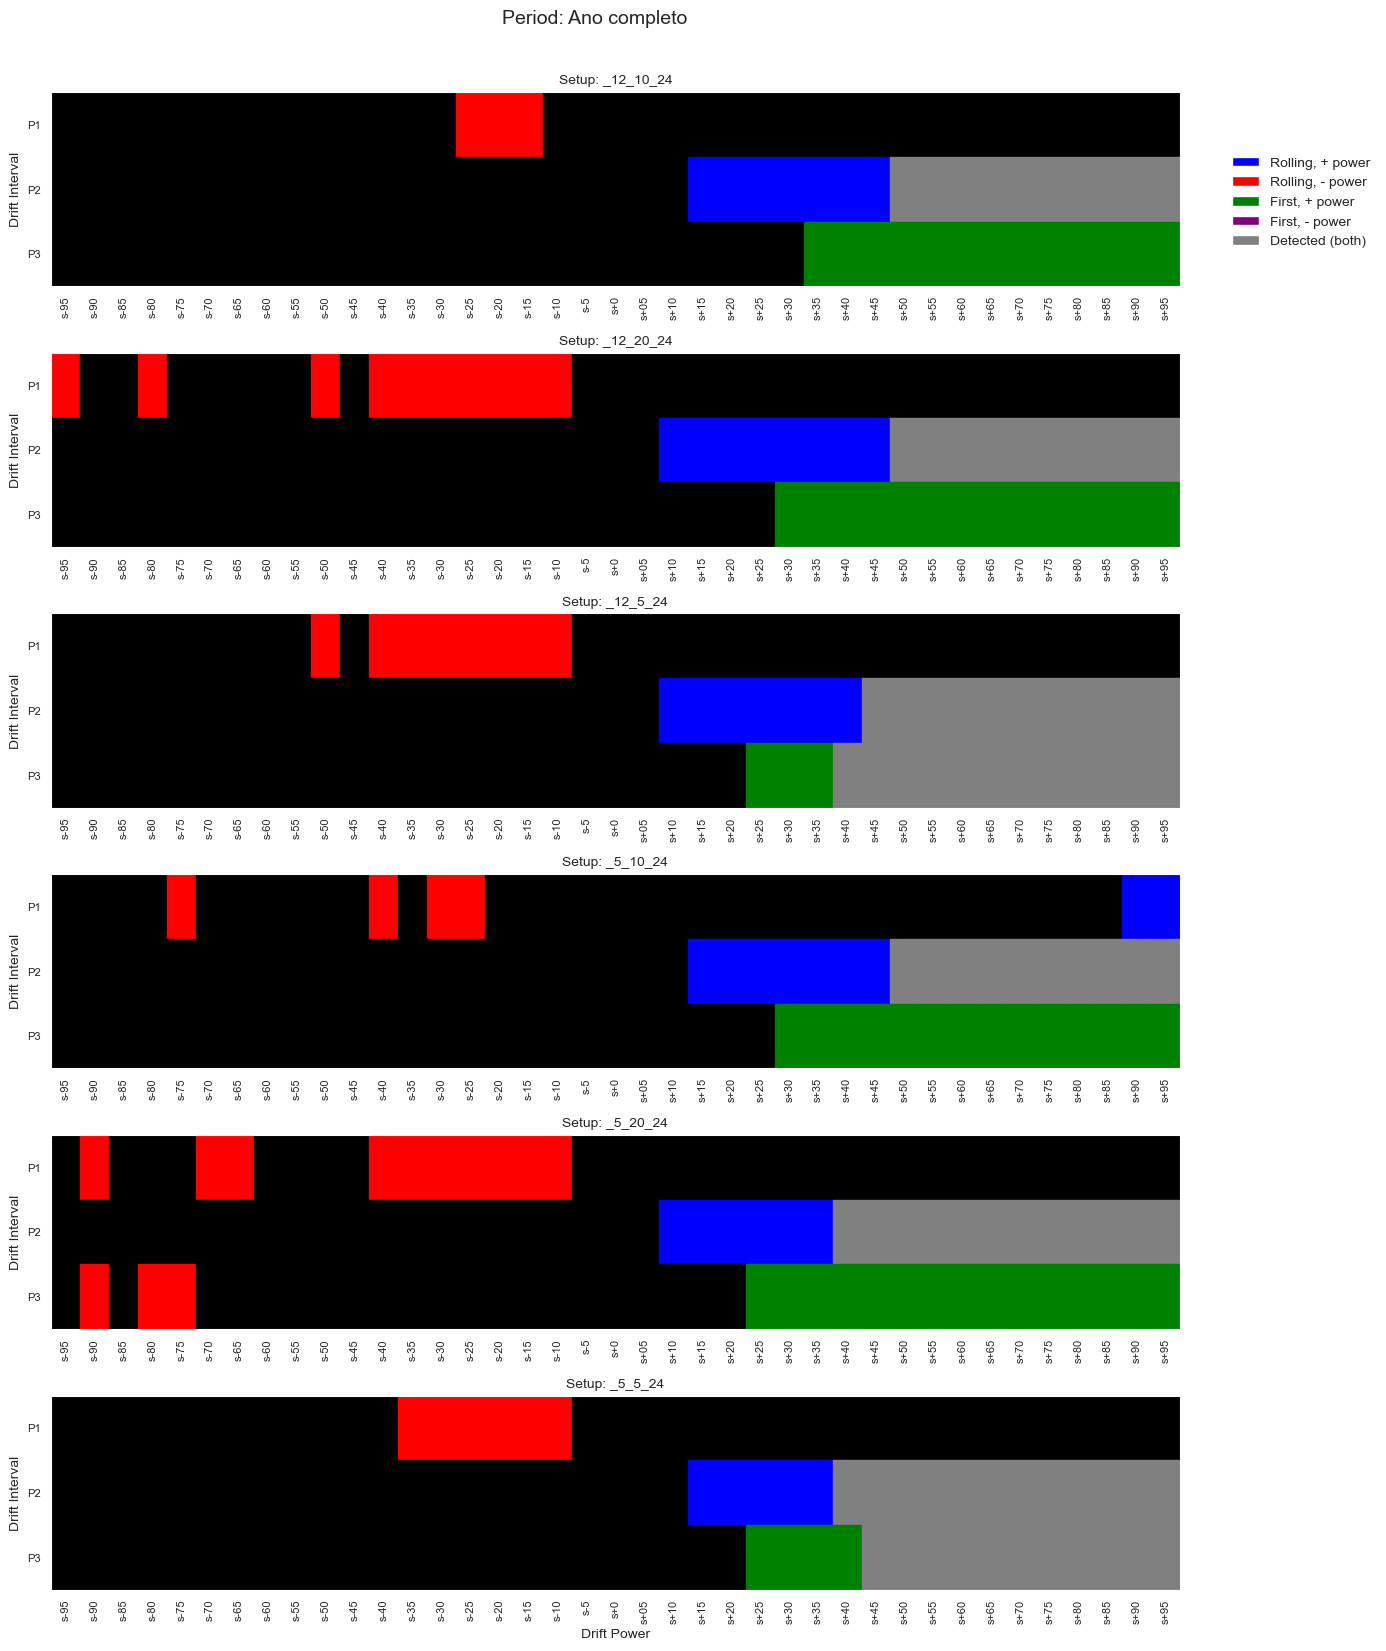

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Ensure drift_power_num exists
def parse_drift_power(val):
    try:
        return int(val.replace('s', '').replace('+', ''))
    except Exception:
        return None

data_exp['drift_power_num'] = data_exp['drift_power'].apply(parse_drift_power)

# --- Extract unique values ---
periods = sorted(data_exp['period'].unique())
setups = sorted(data_exp['setup'].unique())

# --- Plot per period ---
for period in periods:
    fig, axes = plt.subplots(len(setups), 1, figsize=(12, 2.8 * len(setups)), squeeze=False)

    for i, setup_exp in enumerate(setups):
        ax = axes[i][0]

        # Subset for this period and setup
        subset = data_exp[
            (data_exp['period'] == period) &
            (data_exp['setup'] == setup_exp) &
            (data_exp['drift_power_num'] < 100)
        ].copy()

        if subset.empty:
            ax.axis('off')
            continue

        # Pivot table: rows = drift_interval, columns = drift_power_num
        subset = subset.sort_values('drift_power_num')
        pivot_color = subset.pivot_table(
            index='drift_interval',
            columns='drift_power_num',
            values='color',
            aggfunc='first'
        )

        # Prepare labels
        x_keys = sorted(pivot_color.columns)
        y_labels = list(pivot_color.index)

        # Mapping for pretty x-axis labels
        drift_power_map = (
            subset[['drift_power_num', 'drift_power']]
            .drop_duplicates()
            .sort_values('drift_power_num')
            .set_index('drift_power_num')['drift_power']
            .to_dict()
        )
        x_labels = [drift_power_map.get(x, str(x)) for x in x_keys]

        # Draw heatmap cells
        for y_idx, y in enumerate(y_labels):
            for x_idx, x in enumerate(x_keys):
                color = pivot_color.loc[y, x] if x in pivot_color.columns else 'white'
                ax.add_patch(plt.Rectangle((x_idx, y_idx), 1, 1, color=color))

        # Axes formatting
        ax.set_xticks([k + 0.5 for k in range(len(x_keys))])
        ax.set_xticklabels(x_labels, rotation=90, fontsize=8)
        ax.set_yticks([k + 0.5 for k in range(len(y_labels))])
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.set_xlim(0, len(x_keys))
        ax.set_ylim(0, len(y_labels))
        ax.invert_yaxis()

        ax.set_title(f"Setup: {setup_exp}", fontsize=10)
        ax.set_ylabel("Drift Interval")

    # Only add xlabel and legend once (at bottom plot)
    axes[-1][0].set_xlabel("Drift Power")

    legend_elements = [
        Patch(facecolor='blue', label='Rolling, + power'),
        Patch(facecolor='red', label='Rolling, - power'),
        Patch(facecolor='green', label='First, + power'),
        Patch(facecolor='purple', label='First, - power'),
        Patch(facecolor='gray', label='Detected (both)'),
    ]
    fig.suptitle(f"Period: {period}", fontsize=14)
    fig.legend(handles=legend_elements, bbox_to_anchor=(1.02, 0.9), loc='upper left', frameon=False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Classify detection per (exp_id, period)
def classify_drift_detection(group):
    types_detected = set(group.loc[group['detected'], 'drift_type'])
    if types_detected == {'first_vs_later'}:
        return 'first_only'
    elif types_detected == {'rolling'}:
        return 'rolling_only'
    elif types_detected == {'first_vs_later', 'rolling'}:
        return 'both'
    else:
        return 'none'

def classify_drift_detection_wrapper(group):
    # drop grouping columns manually
    group_data = group.drop(columns=['exp_id', 'period', 'setup'], errors='ignore')

    label = classify_drift_detection(group_data)

    return pd.Series({'detection_label': label})


def label_based_color(row):
    label = row['detection_label']
    drift_power = row['drift_power']

    if pd.isnull(label):
        return 'black'
    if label == 'both':
        return 'gray'
    if '+' in drift_power:
        sign = '+'
    elif '-' in drift_power:
        sign = '-'
    else:
        return 'black'

    if 'rolling' in label:
        return 'blue' if sign == '+' else 'red'
    if 'first' in label:
        return 'green' if sign == '+' else 'purple'
    return 'black'

def parse_drift_power(val):
    try:
        return int(val.replace('s', '').replace('+', ''))
    except Exception:
        return None


# --- 1. Preprocessing ---
data_exp = results_evaluation.copy()

# Extract metadata from exp_id
data_exp[['drift_interval', 'drift_power', 'feats']] = (
    data_exp['exp_id'].str.replace('R', 'P').str.split('_', expand=True)
)
data_exp['drift_positive'] = data_exp['drift_power'].str.contains(r'\+')
data_exp['feats'] = data_exp['feats'].str.replace('f', '')
data_exp = data_exp[data_exp['feats'] == '1']

# Filter for method
data_exp = data_exp[data_exp['method'] == 'summary'].copy()

# Flag detection
data_exp['detected'] = data_exp['correct_%'] != 0
data_exp['period'].unique()


# Group the data
grouped = data_exp.groupby(['setup', 'exp_id', 'period'], group_keys=False)

# Apply function and avoid deprecated behavior manually
drift_labels = grouped.apply(classify_drift_detection_wrapper, include_groups=False).reset_index()
drift_labels.columns = ['setup', 'exp_id', 'period', 'detection_label']

# Merge results back
data_exp = data_exp.merge(drift_labels, on=['setup', 'exp_id', 'period'], how='left')

# Composite identifier for y-axis
data_exp['drift_exp'] = data_exp['drift_type'] + " | " + data_exp['feats']

# --- 2. Define color mapping ---

# Assign color
data_exp['color'] = data_exp.apply(label_based_color, axis=1)


data_exp['period'] = data_exp['period'].str.replace('all_periods', 'Ano completo')
data_exp['period'] = data_exp['period'].str.replace('first_4_months', '1_trimestre')
data_exp['period'] = data_exp['period'].str.replace('middle_year', '2_trimestre')
data_exp['period'] = data_exp['period'].str.replace('final_year', '3_trimestre')

data_exp['drift_power_num'] = data_exp['drift_power'].apply(parse_drift_power)
# --- 3. Plot per (period, drift_interval) ---
periods = sorted(data_exp['period'].unique())
intervals = sorted(data_exp['drift_interval'].unique())


array(['all_year'], dtype=object)

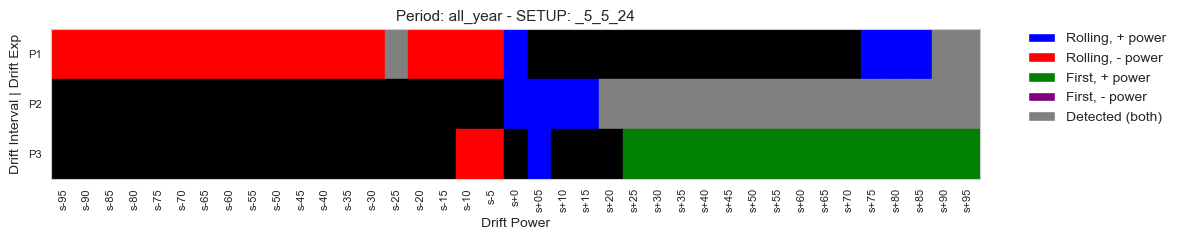

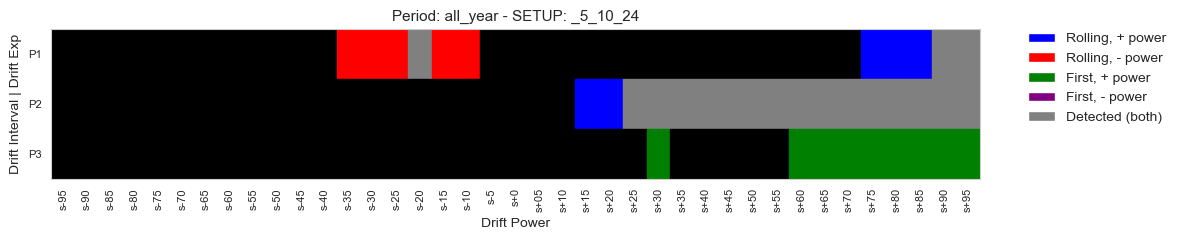

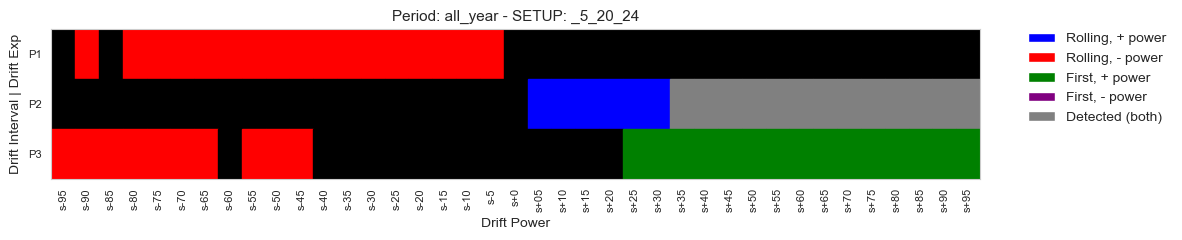

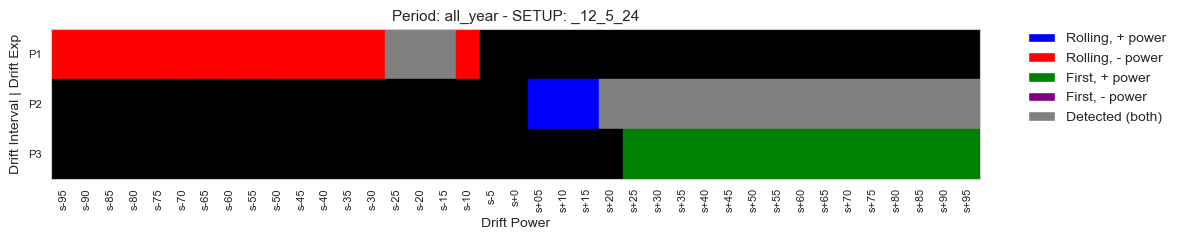

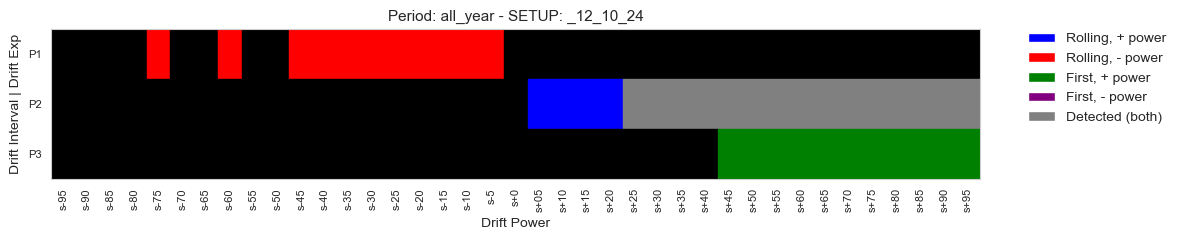

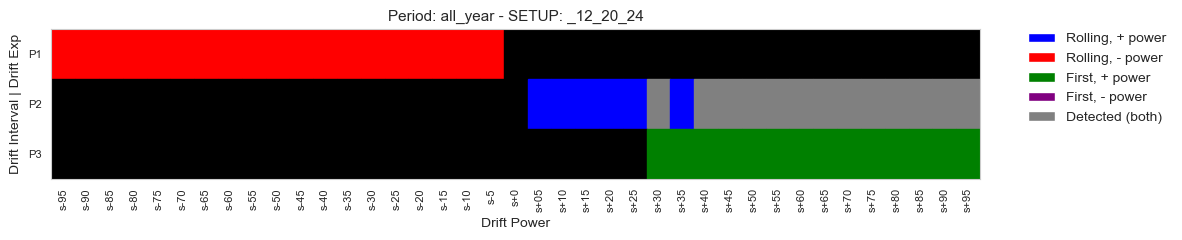

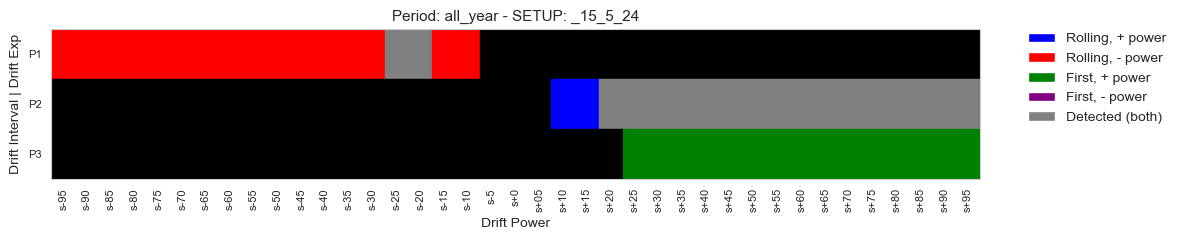

In [20]:


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Plot per period (stacked by drift_interval) ---
for setup_exp in ['_5_5_24', '_5_10_24', '_5_20_24', '_12_5_24', '_12_10_24', '_12_20_24', '_15_5_24', ]:#data_exp['setup'].unique():
    data_exp_setup = data_exp[data_exp['setup'] == setup_exp]

    fig, axes = plt.subplots(len(periods), 1, figsize=(10, 2.5 * len(periods)), squeeze=False)

    for i, period in enumerate(periods):
        ax = axes[i][0]

        # Subset for this period
        subset = data_exp_setup[data_exp_setup['period'] == period].copy()
        if subset.empty:
            ax.axis('off')
            continue

        # Combine drift_interval and drift_exp into one row label
        subset = subset[subset['drift_power_num'] < 100]

        # Sort and pivot
        subset = subset.sort_values('drift_power_num')
        pivot_color = subset.pivot_table(
            index='drift_interval',
            columns='drift_power_num',
            values='color',
            aggfunc='first'
        )

        # Get sorted labels
        x_keys = sorted(pivot_color.columns)
        y_labels = list(pivot_color.index)

        # Get drift_power labels (e.g., 's+05') for x-ticks
        drift_power_map = (
            subset[['drift_power_num', 'drift_power']]
            .drop_duplicates()
            .sort_values('drift_power_num')
            .set_index('drift_power_num')['drift_power']
            .to_dict()
        )
        x_labels = [drift_power_map.get(x, str(x)) for x in x_keys]

        # Draw heatmap
        for y_idx, y in enumerate(y_labels):
            for x_idx, x in enumerate(x_keys):
                color = pivot_color.loc[y, x] if x in pivot_color.columns else 'white'
                ax.add_patch(plt.Rectangle((x_idx, y_idx), 1, 1, color=color))

        # Axes formatting
        ax.set_xticks([k + 0.5 for k in range(len(x_keys))])
        ax.set_xticklabels(x_labels, rotation=90, fontsize=8)
        ax.set_yticks([k + 0.5 for k in range(len(y_labels))])
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.set_xlim(0, len(x_keys))
        ax.set_ylim(0, len(y_labels))
        ax.invert_yaxis()

        ax.set_title(f"Period: {period} - SETUP: {setup_exp}", fontsize=11)
        ax.set_xlabel("Drift Power")
        ax.set_ylabel("Drift Interval | Drift Exp")

    # Legend
    legend_elements = [
        Patch(facecolor='blue', label='Rolling, + power'),
        Patch(facecolor='red', label='Rolling, - power'),
        Patch(facecolor='green', label='First, + power'),
        Patch(facecolor='purple', label='First, - power'),
        Patch(facecolor='gray', label='Detected (both)'),
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(1.02, 0.9), loc='upper left', frameon=False)

    plt.tight_layout()
    plt.show()

In [17]:
file_paths_a = glob.glob(f'data_leaks/benchmark/energy/R*')
file_paths_b = glob.glob(f'data_leaks/benchmark/energy/P*')

# file_paths = [f for f in file_paths if 's+' in f]
# file_paths = [f for f in file_paths if '2_' not in f]

file_paths = file_paths_a + file_paths_b

for i in range(2, 7):
    file_paths = [f for f in file_paths if f'{i}feats' not in f]

file_paths = [f for f in file_paths if '0_' in f]
file_paths

['data_leaks/benchmark/energy\\R1_s+0_1feats',
 'data_leaks/benchmark/energy\\R1_s+10_1feats',
 'data_leaks/benchmark/energy\\R1_s+20_1feats',
 'data_leaks/benchmark/energy\\R1_s+30_1feats',
 'data_leaks/benchmark/energy\\R1_s+40_1feats',
 'data_leaks/benchmark/energy\\R1_s+50_1feats',
 'data_leaks/benchmark/energy\\R1_s+60_1feats',
 'data_leaks/benchmark/energy\\R1_s+70_1feats',
 'data_leaks/benchmark/energy\\R1_s+80_1feats',
 'data_leaks/benchmark/energy\\R1_s+90_1feats',
 'data_leaks/benchmark/energy\\R1_s-0_1feats',
 'data_leaks/benchmark/energy\\R1_s-10_1feats',
 'data_leaks/benchmark/energy\\R1_s-20_1feats',
 'data_leaks/benchmark/energy\\R1_s-30_1feats',
 'data_leaks/benchmark/energy\\R1_s-40_1feats',
 'data_leaks/benchmark/energy\\R1_s-50_1feats',
 'data_leaks/benchmark/energy\\R1_s-60_1feats',
 'data_leaks/benchmark/energy\\R1_s-70_1feats',
 'data_leaks/benchmark/energy\\R1_s-80_1feats',
 'data_leaks/benchmark/energy\\R1_s-90_1feats',
 'data_leaks/benchmark/energy\\R2_s+0_1fea

In [13]:
file_paths_a = glob.glob(f'data_leaks/benchmark/energy/R*')
file_paths_a[0]

'data_leaks/benchmark/energy\\R1_s+0_1feats'

In [76]:
import pickle
with open('results/energy/P3_s-20_1feats_3_2_24_10_BENCHMARK_ENERGY_FINAL_BORA_2018___10_1_86400___6/results.pkl', 'rb') as f:
    model = pickle.load(f)

model['Baseline']['args']

Namespace(device_id=0, experiment_id='P3_s-20_1feats', extra_coments='BENCHMARK_ENERGY_FINAL_BORA_2018___10_1_86400___6', id_network='Benchmark_energy', seed=72, tgt_district='District_D', drift_income='medium', drift_density='medium', seed_node='12', income_density_mapping=[('medium', 'low'), ('low', 'medium'), ('low', 'high'), ('low', 'low'), ('low', 'low')], run_simulation=False, federated_training=True, process_latents=True, detect_anomalies=False, generate_viz=False, save_extras=False, communication_epoch=3, local_epoch=2, dataset='benchmark', domains={'Benchmark_energy': 5}, interval_agg=86400, window_size=10, step_size=1, input_size=2, output_size=2, lstm_units=30, parti_num=5, online_ratio=1, model='fpl', structure='homogeneity', pri_aug='weak', learning_decay=False, averaging='weight', infoNCET=0.02, T=0.05, weight=1)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Plot per period (stacked by drift_interval) ---
for setup_exp in data_exp['setup'].unique():
    data_exp_setup = data_exp[data_exp['setup'] == setup_exp]

    fig, axes = plt.subplots(len(periods), 1, figsize=(10, 2.5 * len(periods)), squeeze=False)

    for i, period in enumerate(periods):
        ax = axes[i][0]

        # Subset for this period
        subset = data_exp_setup[data_exp_setup['period'] == period].copy()
        if subset.empty:
            ax.axis('off')
            continue

        # Combine drift_interval and drift_exp into one row label
        subset = subset[subset['drift_power_num'] < 100]

        # Sort and pivot
        subset = subset.sort_values('drift_power_num')
        pivot_color = subset.pivot_table(
            index='drift_interval',
            columns='drift_power_num',
            values='color',
            aggfunc='first'
        )

        # Get sorted labels
        x_keys = sorted(pivot_color.columns)
        y_labels = list(pivot_color.index)

        # Get drift_power labels (e.g., 's+05') for x-ticks
        drift_power_map = (
            subset[['drift_power_num', 'drift_power']]
            .drop_duplicates()
            .sort_values('drift_power_num')
            .set_index('drift_power_num')['drift_power']
            .to_dict()
        )
        x_labels = [drift_power_map.get(x, str(x)) for x in x_keys]

        # Draw heatmap
        for y_idx, y in enumerate(y_labels):
            for x_idx, x in enumerate(x_keys):
                color = pivot_color.loc[y, x] if x in pivot_color.columns else 'white'
                ax.add_patch(plt.Rectangle((x_idx, y_idx), 1, 1, color=color))

        # Axes formatting
        ax.set_xticks([k + 0.5 for k in range(len(x_keys))])
        ax.set_xticklabels(x_labels, rotation=90, fontsize=8)
        ax.set_yticks([k + 0.5 for k in range(len(y_labels))])
        ax.set_yticklabels(y_labels, fontsize=8)
        ax.set_xlim(0, len(x_keys))
        ax.set_ylim(0, len(y_labels))
        ax.invert_yaxis()

        ax.set_title(f"Period: {period} - SETUP: {setup_exp}", fontsize=11)
        ax.set_xlabel("Drift Power")
        ax.set_ylabel("Drift Interval | Drift Exp")

    # Legend
    legend_elements = [
        Patch(facecolor='blue', label='Rolling, + power'),
        Patch(facecolor='red', label='Rolling, - power'),
        Patch(facecolor='green', label='First, + power'),
        Patch(facecolor='purple', label='First, - power'),
        Patch(facecolor='gray', label='Detected (both)'),
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(1.02, 0.9), loc='upper left', frameon=False)

    plt.tight_layout()
    plt.show()

In [ ]:
# data_exp = results_evaluation[results_evaluation['setup'] == '_30_1_86400'].copy()
data_exp = results_evaluation.copy()
data_exp = results_evaluation[results_evaluation['period'] == 'all_year'].copy()
# data_exp = results_evaluation[results_evaluation['drift_type'] == 'rolling'].copy()
data_exp[['drift_interval', 'drift_power', 'feats']] = data_exp['exp_id'].str.replace('R', 'P').str.split('_', expand = True)

data_exp['drift_positive'] = data_exp['drift_power'].str.contains(r'\+')
for setup in data_exp['setup'].unique()[1:]:
    print(setup)
    for period in data_exp['period'].unique():
        for drift_positive in data_exp['drift_positive'].unique():
            print(period, drift_positive)
            data_exp_0 = data_exp[data_exp['period'] == period].copy()
            data_exp_0 = data_exp_0[data_exp_0['setup'] == setup]
            data_exp_0 = data_exp_0[data_exp_0['drift_positive'] == drift_positive]
            data_exp_0['feats'] = data_exp_0['feats'].str.replace('f', '')

            data_exp_0 = data_exp_0[data_exp_0['feats'].isin(['1'])]

            x_var = 'drift_exp'
            # data_exp_0[x_var] = data_exp_0['drift_type'] + " | " + data_exp_0['drift_power'] + " | " + data_exp_0['feats']
            data_exp_0[x_var] = data_exp_0['drift_type'] + " | " + data_exp_0['feats']


            col_var = 'drift_power'
            row_var = 'drift_interval'
            hue_var = 'method'

            # Define FacetGrid with tighter spacing
            g = sns.FacetGrid(
                data_exp_0,
                col=col_var,
                row=row_var,
                col_order=data_exp_0[col_var].sort_values().unique(),
                row_order=data_exp_0[row_var].sort_values().unique(),
                margin_titles=True,        # Helps use space better
                despine=False,             # Keeps axes for reference
                height=1.75,                # Smaller subplot height
                aspect=1                   # Adjust aspect ratio (width / height)
            )

            # Map barplot with narrower bars
            g.map_dataframe(
                sns.barplot,
                x=x_var,
                y='correct_%',
                # order=data_exp_0[x_var].sort_values().unique(),
                hue=hue_var,
                hue_order=data_exp_0[hue_var].sort_values().unique(),
                width=.8,
                palette='autumn'
            )

            # Reduce spacing between subplots
            g.fig.subplots_adjust(
                hspace=0.2,  # vertical space between rows
                wspace=0.05  # horizontal space between columns
            )

            # Reduce legend size and move to a compact position
            g.add_legend(title=hue_var)
            # g._legend.set_bbox_to_anchor((1.10, 0.625))  # move legend to side
            g._legend.set_frame_on(False)

            # Optional: Rotate x-ticks and tighten layout
            for ax in g.axes.flat:
                for label in ax.get_xticklabels():
                    label.set_rotation(90)
                    label.set_fontsize(15)
                ax.set_ylabel('')
                ax.set_xlabel('')


            plt.tight_layout()
            plt.savefig(f'results/imgs/bench_{setup}_{period}_{drift_positive}_borexps_summ.pdf')
            # plt.show()
            plt.close()

_14_1_172800 - MAX COSINE
_14_1_172800 - RANK COSINE
_14_1_172800 - SUMMARY
_7_1_172800 - MAX COSINE
_7_1_172800 - RANK COSINE
_7_1_172800 - SUMMARY
_30_1_86400 - MAX COSINE
_30_1_86400 - RANK COSINE
_30_1_86400 - SUMMARY
_21_1_172800 - MAX COSINE
_21_1_172800 - RANK COSINE
_21_1_172800 - SUMMARY
_14_1_172800


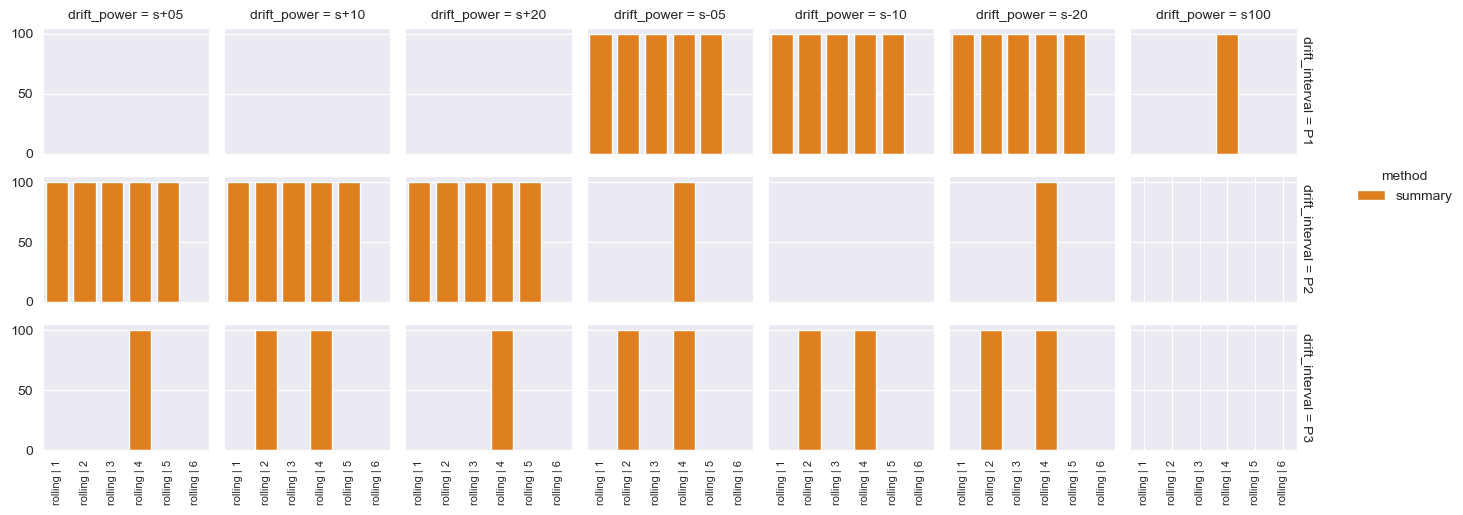

_7_1_172800


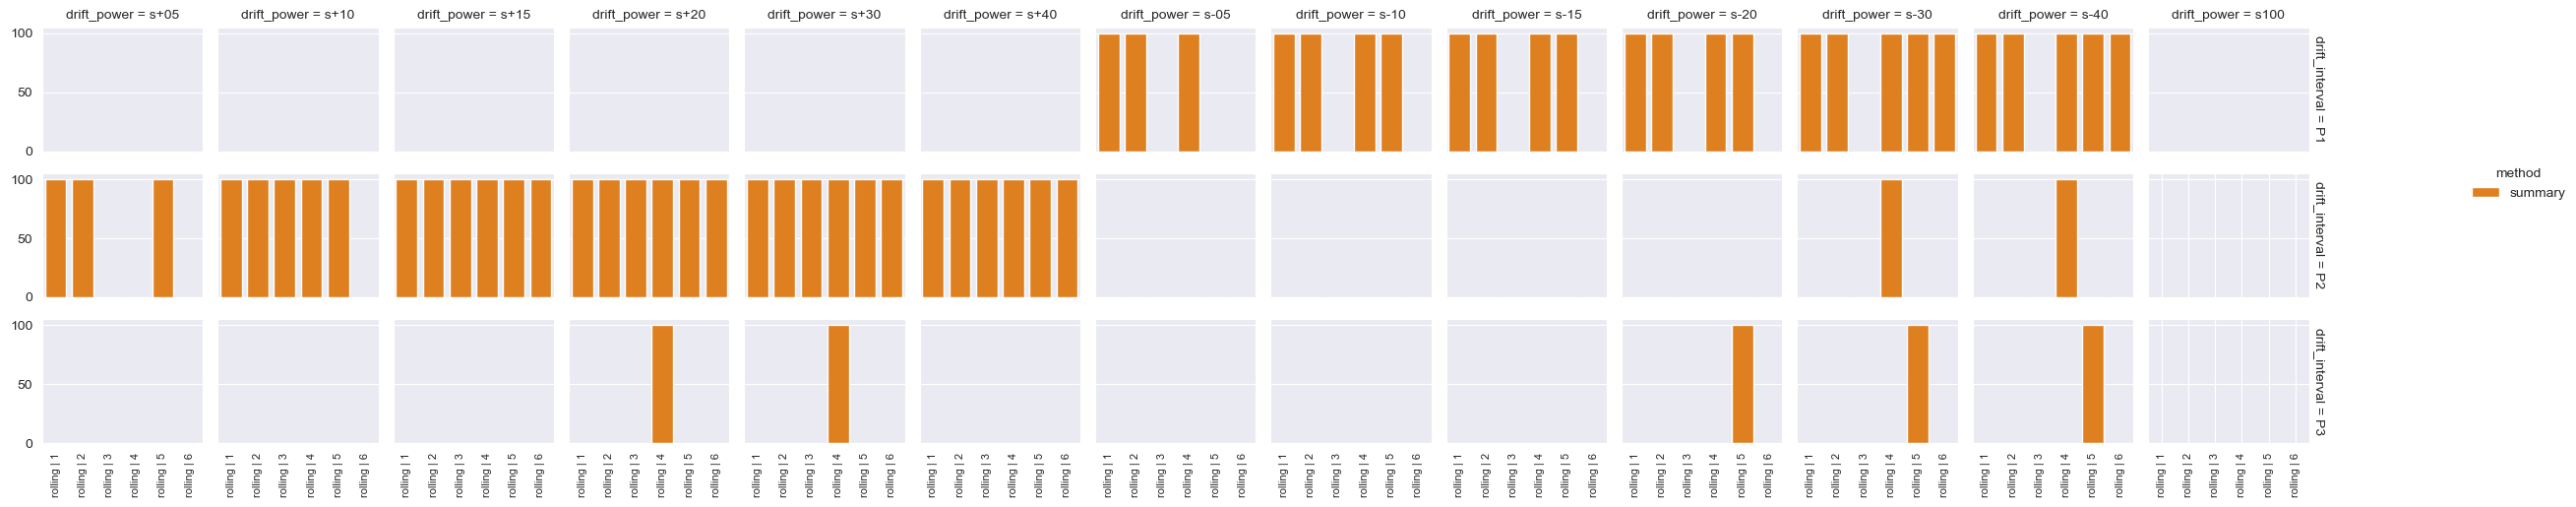

_30_1_86400


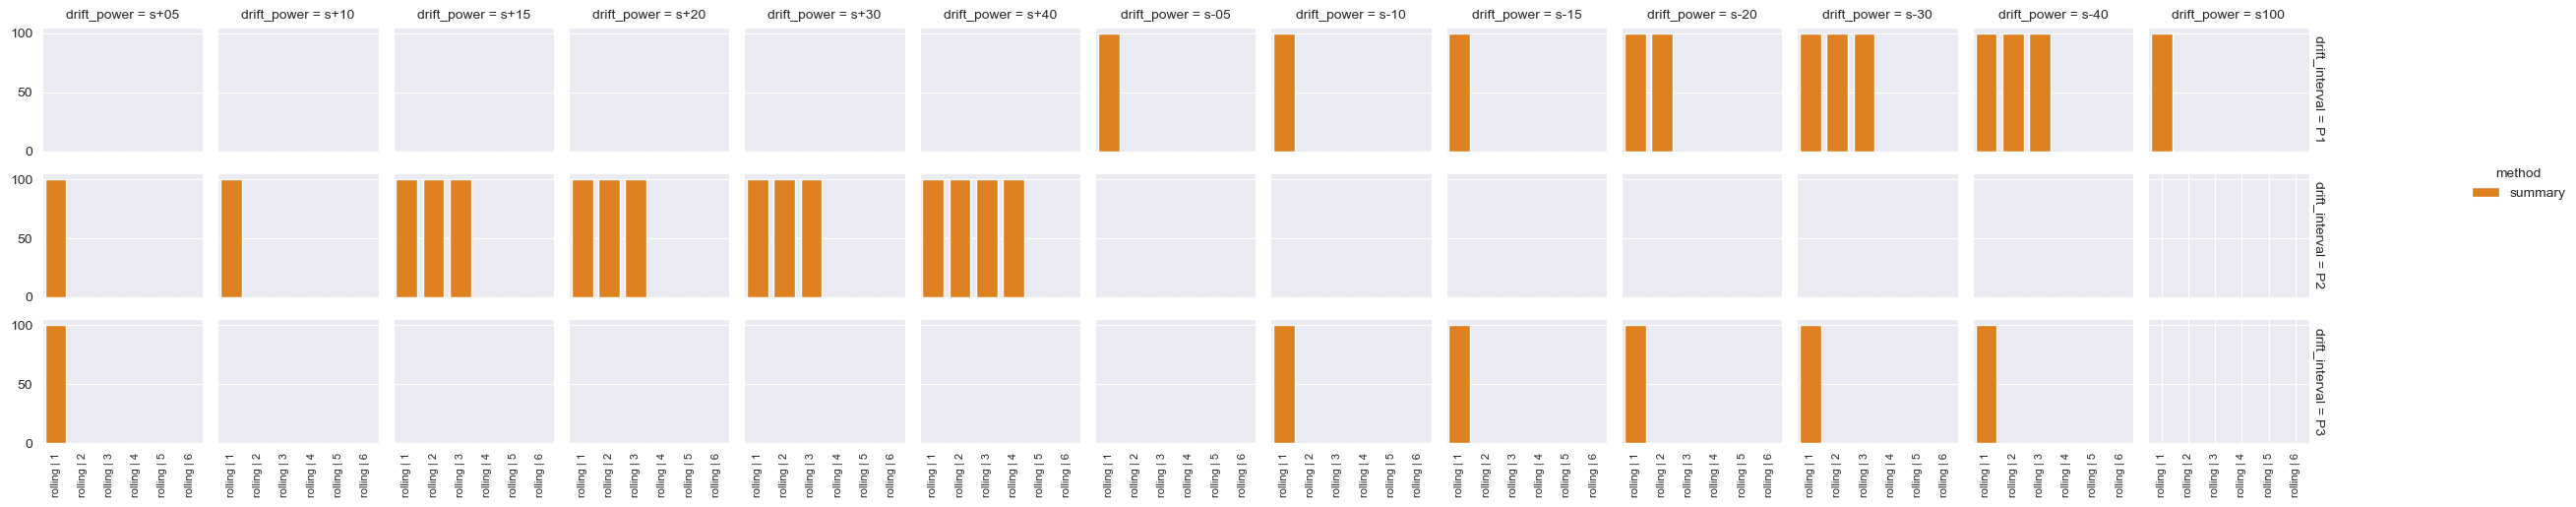

_21_1_172800


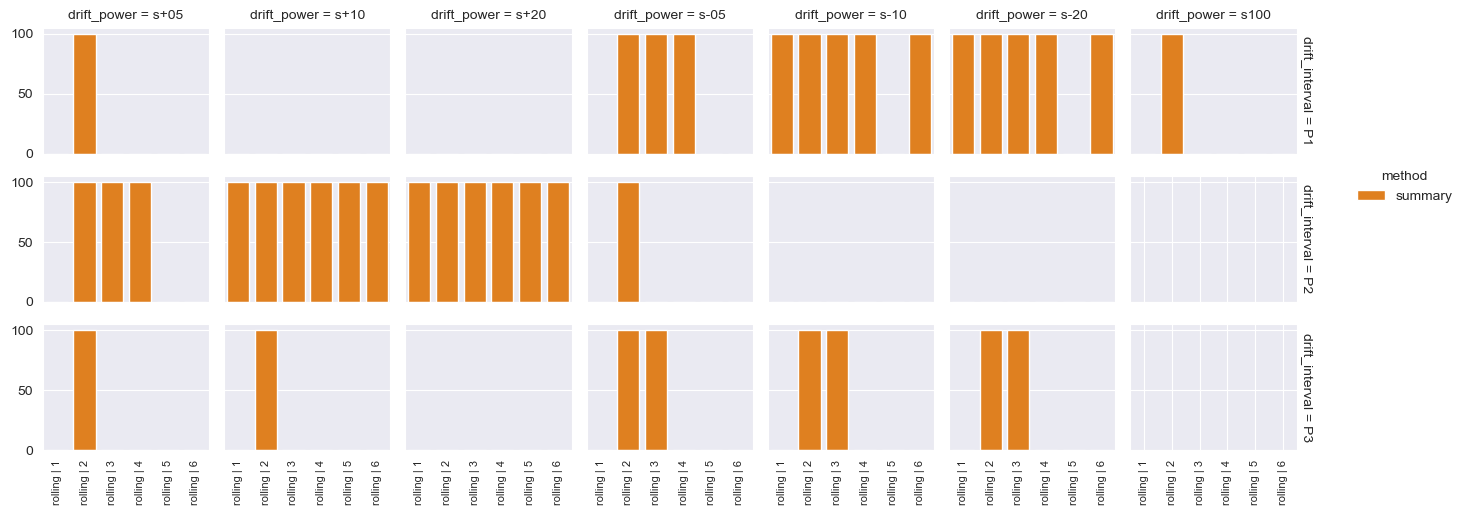

In [59]:
import pickle
with open('results/imgs/experiment_benchmark_energy_analysis_test.pkl', 'rb') as f:
    results_full = pickle.load(f)
    

possible_exps = set([exp.split('__')[-2] for exp in list(results_full.keys())])

setup_dict = {}
for setup in possible_exps:
    exps_setup = [exp for exp in list(results_full.keys()) if setup in exp]
    setup_dict[setup] = exps_setup

extraction_methods = [
    ("max cosine", extract_best_clients_by_max_cosine_distance),
    ("rank cosine", extract_best_clients_by_ranked_summary_initial),
    ("summary", extract_best_clients_by_summary_metrics)
]

results_full_evaluation, summary_df = evaluate_extraction_methods(setup_dict, results_full, extraction_methods)



data_exp = results_full_evaluation[results_full_evaluation['drift_type'] == 'rolling'].copy()
data_exp[['drift_interval', 'drift_power', 'feats']] = data_exp['exp_id'].str.replace('R', 'P').str.split('_', expand = True)

for setup in data_exp['setup'].unique():
    print(setup)
    data_exp_0 = data_exp[data_exp['period'] == 'all_year'].copy()
    data_exp_0 = data_exp_0[data_exp_0['setup'] == setup]

    x_var = 'drift_exp'
    # data_exp_0[x_var] = data_exp_0['drift_type'] + " | " + data_exp_0['drift_power'] + " | " + data_exp_0['feats']
    data_exp_0[x_var] = data_exp_0['drift_type'] + " | " + data_exp_0['feats']

    col_var = 'drift_power'
    row_var = 'drift_interval'
    hue_var = 'method'

    # Define FacetGrid with tighter spacing
    g = sns.FacetGrid(
        data_exp_0,
        col=col_var,
        row=row_var,
        col_order=data_exp_0[col_var].sort_values().unique(),
        row_order=data_exp_0[row_var].sort_values().unique(),
        margin_titles=True,        # Helps use space better
        despine=False,             # Keeps axes for reference
        height=1.75,                # Smaller subplot height
        aspect=1                   # Adjust aspect ratio (width / height)
    )

    # Map barplot with narrower bars
    g.map_dataframe(
        sns.barplot,
        x=x_var,
        y='correct_%',
        # order=data_exp_0[x_var].sort_values().unique(),
        hue=hue_var,
        hue_order=data_exp_0[hue_var].sort_values().unique(),
        width=.8,
        palette='autumn'
    )

    # Reduce spacing between subplots
    g.fig.subplots_adjust(
        hspace=0.2,  # vertical space between rows
        wspace=0.05  # horizontal space between columns
    )

    # Reduce legend size and move to a compact position
    g.add_legend(title=hue_var)
    g._legend.set_bbox_to_anchor((1.10, 0.625))  # move legend to side
    g._legend.set_frame_on(False)

    # Optional: Rotate x-ticks and tighten layout
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(90)
            label.set_fontsize(8)
        ax.set_ylabel('')
        ax.set_xlabel('')


    plt.tight_layout()
    plt.show()

In [10]:
import zipfile

# Path to the ZIP file
zip_path = 'results/NEW_WINDOW.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_names = zip_ref.namelist()

file_names[:5]

['A_62_LL_LM__LL_ML_HL_LM_HM_10_1_3_84_NEW_WINDOW_LL_ML_HL_LM_HM__84_63_10800___0/',
 'A_62_LL_LM__LL_ML_HL_LM_HM_10_1_3_84_NEW_WINDOW_LL_ML_HL_LM_HM__84_63_10800___0/Baseline_pca.parquet',
 'A_62_LL_LM__LL_ML_HL_LM_HM_10_1_3_84_NEW_WINDOW_LL_ML_HL_LM_HM__84_63_10800___0/Baseline_proto.parquet',
 'A_62_LL_LM__LL_ML_HL_LM_HM_10_1_3_84_NEW_WINDOW_LL_ML_HL_LM_HM__84_63_10800___0/Baseline_umap.parquet',
 'A_62_LL_LM__LL_ML_HL_LM_HM_10_1_3_84_NEW_WINDOW_LL_ML_HL_LM_HM__84_63_10800___0/Proto_Similarities.html']

In [12]:
bkp = file_names.copy()

In [129]:
exp_names = [f for f in file_names if 'parquet' not in f]
exp_names = [f for f in exp_names if 'html' not in f]
exp_names = [f.replace('___0/', '') for f in exp_names if 'pkl' not in f]

rows = []

for filename in exp_names:
    parts = filename.split('__')

    if len(parts) == 3:
        prefix, window_part, suffix = parts
        # Split the window part at 'NEW_WINDOW'
        before_window, after_window = window_part.split('_NEW_WINDOW_')

        row = {
            'prefix': prefix,
            'before_window': before_window[15:],
            'after_window': after_window,
            'suffix': suffix
        }
        rows.append(row)
    else:
        print(f"Skipping invalid format: {filename}")

# Create DataFrame
df = pd.DataFrame(rows)

df[['window', 'step_size', 'interval']] = df['suffix'].str.split('_', expand = True).astype(int)
df[['com_epoch', 'loc_epoch', 'agg', 'window_check']] = df['before_window'].str.split('_', expand = True).astype(int)

df['step_ratio'] = round(df['step_size']  / df['window'], 3)
df['init_state'] = df['prefix'].str[5:7]
df['final_state'] = df['prefix'].str[-2:]

df[['A', 'B', 'C', 'D', 'E']] = df['after_window'].str.split('_', expand = True)

df = df[['init_state', 'final_state', 'B', 'C', 'D', 'E', 'agg', 'window',
       'step_size', 'step_ratio']]


target_cols = ['B', 'C', 'D', 'E']
df['match_init'] = df[target_cols].eq(df['init_state'], axis=0).sum(axis=1)
df['match_final'] = df[target_cols].eq(df['final_state'], axis=0).sum(axis=1)

# Get last character of final_state
df['final_last_char'] = df['final_state'].str[-1]

# Get last character of each target column and compare
df['match_final_last_char'] = (
    df[target_cols].apply(lambda x: x.str[-1], axis=1)
    .eq(df['final_last_char'], axis=0)
    .sum(axis=1)
)

df = df[df['match_final'] == 1]
df_density = df[df['final_state'] != 'ML']

df.head()

,init_state,final_state,B,C,D,E,agg,window,step_size,step_ratio,match_init,match_final,final_last_char,match_final_last_char
0,LL,LM,ML,HL,LM,HM,3,84,63,0.75,0,1,M,2
1,LL,LM,MM,HL,ML,LM,3,84,63,0.75,0,1,M,2
2,LL,LM,LL,LH,LM,LL,3,84,63,0.75,2,1,M,1
3,LL,LM,LL,LM,LH,LL,3,84,63,0.75,2,1,M,1
4,LL,LM,LH,LL,LL,LM,3,84,63,0.75,2,1,M,1


In [151]:
df_density_P1 = df_density[(df_density['step_ratio'] == .444) | (df_density['step_ratio'] == .333)]
combined_value_counts(df_density_P1['agg'], normalize=False, sort_index=True)

,count,percent
agg,,
4,36,0.333333
6,36,0.333333
12,36,0.333333


In [152]:
df_density_P2 = df_density[(df_density['step_ratio'] != .444) & (df_density['step_ratio'] != .333)]
df_density_P1B = df_density_P2[df_density_P2['agg'] == 4]
df_density_P2 = df_density_P2[df_density_P2['agg'] != 4]

df_density_P2[['step_ratio', 'agg']].value_counts().sort_index()
combined_value_counts(df_density_P2[['step_ratio', 'agg']], normalize=False, sort_index=True)

count   percent
step_ratio agg                 
0.250      2      108  0.134831
           3       18  0.022472
           6       54  0.067416
           12      36  0.044944
0.500      2      108  0.134831
           3       36  0.044944
           6       72  0.089888
           12      54  0.067416
0.667      6       54  0.067416
           12      54  0.067416
0.750      2      108  0.134831
           3        9  0.011236
           6       54  0.067416
           12      36  0.044944

In [153]:
combined_value_counts(df_density_P1B['step_ratio'], normalize=False, sort_index=True)

,count,percent
step_ratio,,
0.500,54,0.5
0.667,54,0.5


In [155]:
combined_value_counts(df_density_P2['window'], normalize=False, sort_index=True)

,count,percent
window,,
3,36,0.044944
6,72,0.089888
9,36,0.044944
12,162,0.202247
48,162,0.202247
84,99,0.123596
144,108,0.134831
168,72,0.089888
360,54,0.067416


In [156]:
df_density_P2[df_density_P2['window'] == 3]

,init_state,final_state,B,C,D,E,agg,window,step_size,step_ratio,match_init,match_final,final_last_char,match_final_last_char
845,LL,LH,LL,LL,LH,LM,12,3,2,0.667,2,1,H,1
847,LL,LH,LL,LM,LH,LL,6,3,2,0.667,2,1,H,1
849,LL,LH,LH,LM,LL,LL,12,3,2,0.667,2,1,H,1
854,LL,LH,LH,LL,LL,LM,12,3,2,0.667,2,1,H,1
861,LL,LM,MM,HL,ML,LM,12,3,2,0.667,0,1,M,2
864,LL,LH,LL,LL,LM,LH,12,3,2,0.667,2,1,H,1
865,LL,LM,LL,LL,LH,LM,12,3,2,0.667,2,1,M,1
1009,LL,LH,LH,HM,MH,ML,12,3,2,0.667,0,1,H,2
1010,LL,LH,HL,ML,LH,LL,12,3,2,0.667,1,1,H,1
1011,LL,LH,LL,LH,LM,LL,12,3,2,0.667,2,1,H,1


In [24]:
file_paths_a = glob.glob(f'data_leaks/benchmark/energy/R*')
# file_paths_b = glob.glob(f'data_leaks/benchmark/energy/P*')

file_paths = file_paths_a #+ file_paths_b
file_paths = [f for f in file_paths if 's-' in f]
file_paths = [f for f in file_paths if '2_' not in f]

for i in range(2, 7):
    file_paths = [f for f in file_paths if f'{i}feats' not in f]

file_paths

['data_leaks/benchmark/energy\\R1_s-0_1feats',
 'data_leaks/benchmark/energy\\R1_s-10_1feats',
 'data_leaks/benchmark/energy\\R1_s-15_1feats',
 'data_leaks/benchmark/energy\\R1_s-20_1feats',
 'data_leaks/benchmark/energy\\R1_s-25_1feats',
 'data_leaks/benchmark/energy\\R1_s-30_1feats',
 'data_leaks/benchmark/energy\\R1_s-35_1feats',
 'data_leaks/benchmark/energy\\R1_s-40_1feats',
 'data_leaks/benchmark/energy\\R1_s-45_1feats',
 'data_leaks/benchmark/energy\\R1_s-50_1feats',
 'data_leaks/benchmark/energy\\R1_s-55_1feats',
 'data_leaks/benchmark/energy\\R1_s-5_1feats',
 'data_leaks/benchmark/energy\\R1_s-60_1feats',
 'data_leaks/benchmark/energy\\R1_s-65_1feats',
 'data_leaks/benchmark/energy\\R1_s-70_1feats',
 'data_leaks/benchmark/energy\\R1_s-75_1feats',
 'data_leaks/benchmark/energy\\R1_s-80_1feats',
 'data_leaks/benchmark/energy\\R1_s-85_1feats',
 'data_leaks/benchmark/energy\\R1_s-90_1feats',
 'data_leaks/benchmark/energy\\R1_s-95_1feats',
 'data_leaks/benchmark/energy\\R3_s-0_1fea